In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error, precision_recall_fscore_support, roc_curve, roc_auc_score, r2_score, make_scorer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


import warnings
warnings.filterwarnings("ignore")

### Wine Recognition Dataset

Dataset shape: (178, 14)

First few rows:
   class  alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24        2.59  2.87               21.0        118   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   color_intensity   hue  od280_od315  proline  
0             5.64  1.04         3.92     1065  
1             4.38

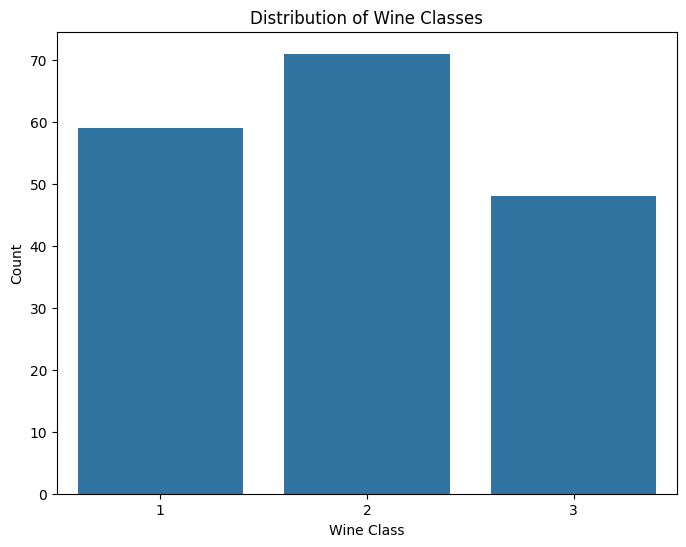

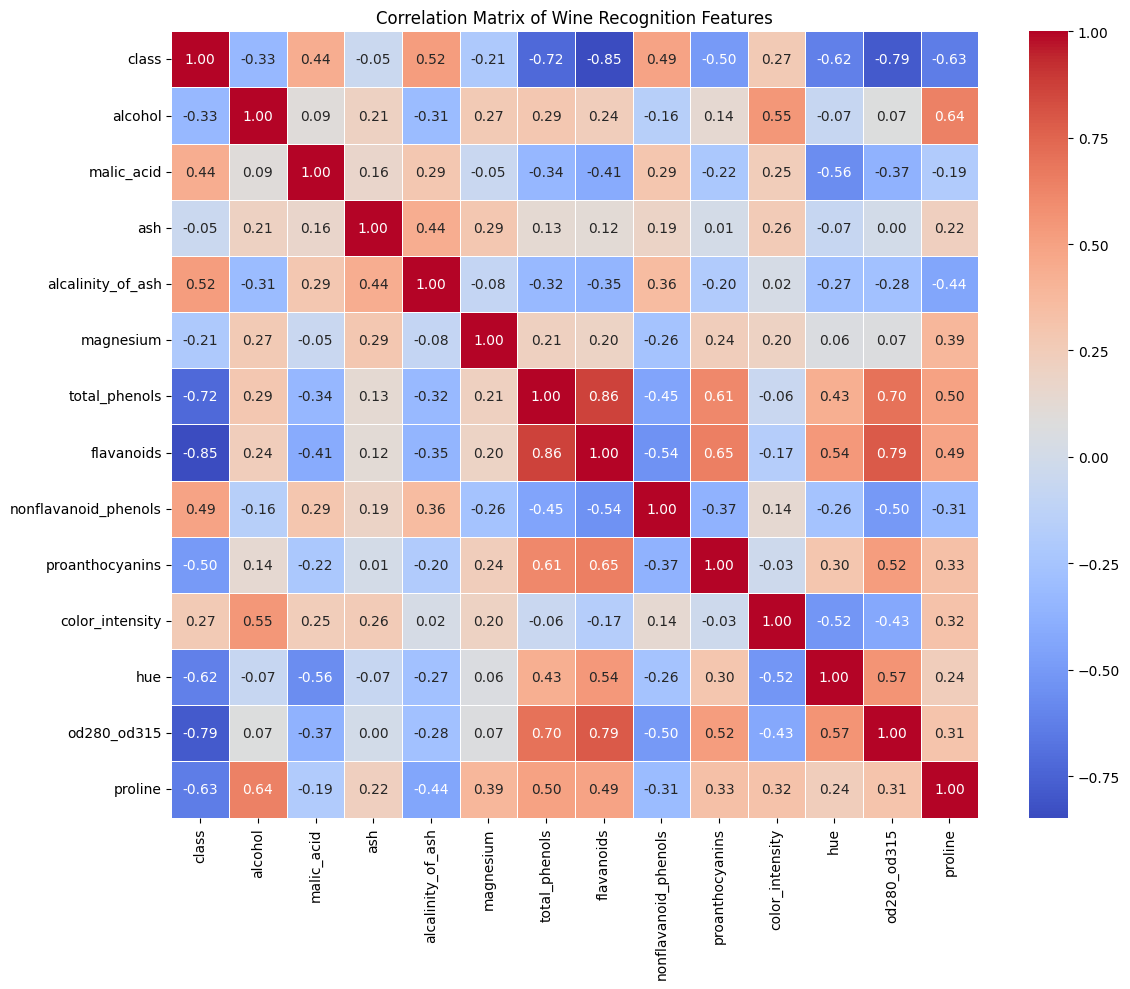

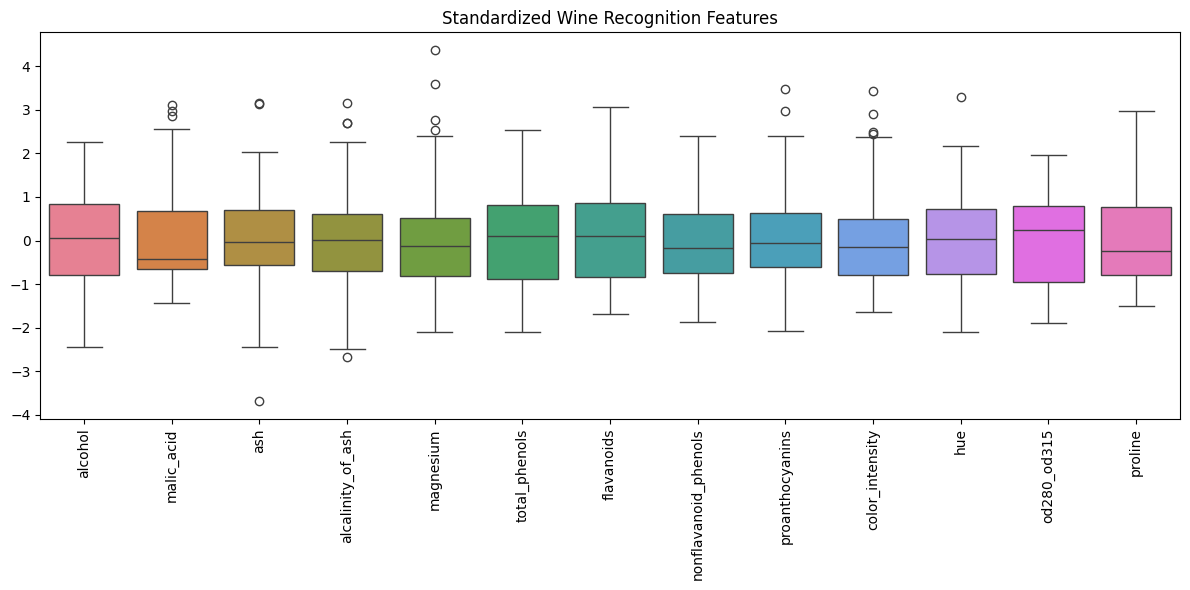

In [5]:
# Load the wine recognition dataset
wine_file = "Wine/wine.data"
wine_columns = ['class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 
                'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
                'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline']

try:
    wine = pd.read_csv(wine_file, header=None, names=wine_columns)
except:
    print(f"Error: Could not find or read {wine_file}")
    exit(1)

# Display information
print(f"Dataset shape: {wine.shape}")
print("\nFirst few rows:")
print(wine.head())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(wine.describe())

# Check for missing values
missing_values = wine.isnull().sum()
print("\nMissing values:")
print(missing_values)

# Distribution of the target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=wine)
plt.title('Distribution of Wine Classes')
plt.xlabel('Wine Class')
plt.ylabel('Count')
plt.show()
plt.close()

# Correlation analysis
plt.figure(figsize=(12, 10))
corr_matrix = wine.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Wine Recognition Features')
plt.tight_layout()
plt.show()
plt.close()

# Preprocessing
# 1. Feature and target separation
X_wine = wine.drop('class', axis=1)
y_wine = wine['class']

# 2. Handle missing values if any
if missing_values.sum() > 0:
    imputer = SimpleImputer(strategy='median')
    X_wine = pd.DataFrame(imputer.fit_transform(X_wine), columns=X_wine.columns)

# 3. Standardize features
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)
X_wine_scaled_df = pd.DataFrame(X_wine_scaled, columns=X_wine.columns)

# 4. Train-test split
X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine_scaled, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

# 5. Visualize the standardized data
plt.figure(figsize=(12, 6))
sns.boxplot(data=X_wine_scaled_df)
plt.title('Standardized Wine Recognition Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
plt.close()

# Save preprocessed data
wine_processed = pd.DataFrame(X_wine_scaled, columns=X_wine.columns)
wine_processed['class'] = y_wine
wine_processed.to_csv('Wine/wine_recognition_processed.csv', index=False)

##### **Motivation for Selection Wine Dataset**
This dataset presents a well defined classification challenge for machine learning. It has three distinct wine cultivars classes which makes this dataset ideal for showing the effectiveness of different classification models. It has moderate size and clean structure with 13 numeric features. This dataset demonstrates how machine learning can be applied to quality assessment of food and beverages.

##### **Prior Research on Wine Dataset**
Dhaliwal, P., Sharma, S., & Chauhan, L. (2022). *Detailed Study of Wine Dataset and its Optimization*. International Journal of Intelligent Systems and Applications (IJISA), 14(5), 35–46. [https://doi.org/10.5815/ijisa.2022.05.04](https://doi.org/10.5815/ijisa.2022.05.04)

In this paper, researchers have implemented a variety of machine learning techniques ranging from classical classifiers like Support Vector Machines and Random Forests to ensemble and neural‐network models in order to predict wine quality or type. Reported accuracies span from around 78 % to as high as 96 % and with ensemble frameworks achieving above 88.5 % and deep neural approaches yielding f1‐scores up to 0.96


### Wine Quality Dataset

Dataset shape: (4898, 12)

First few rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  

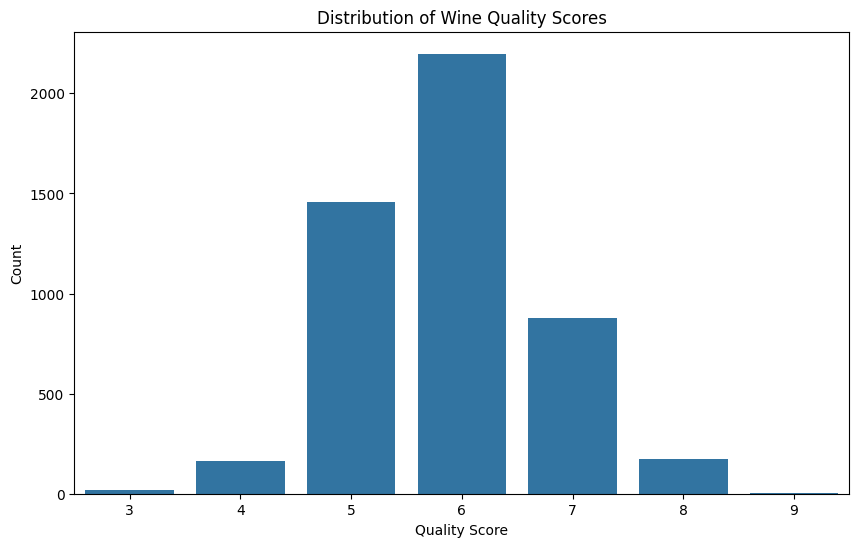

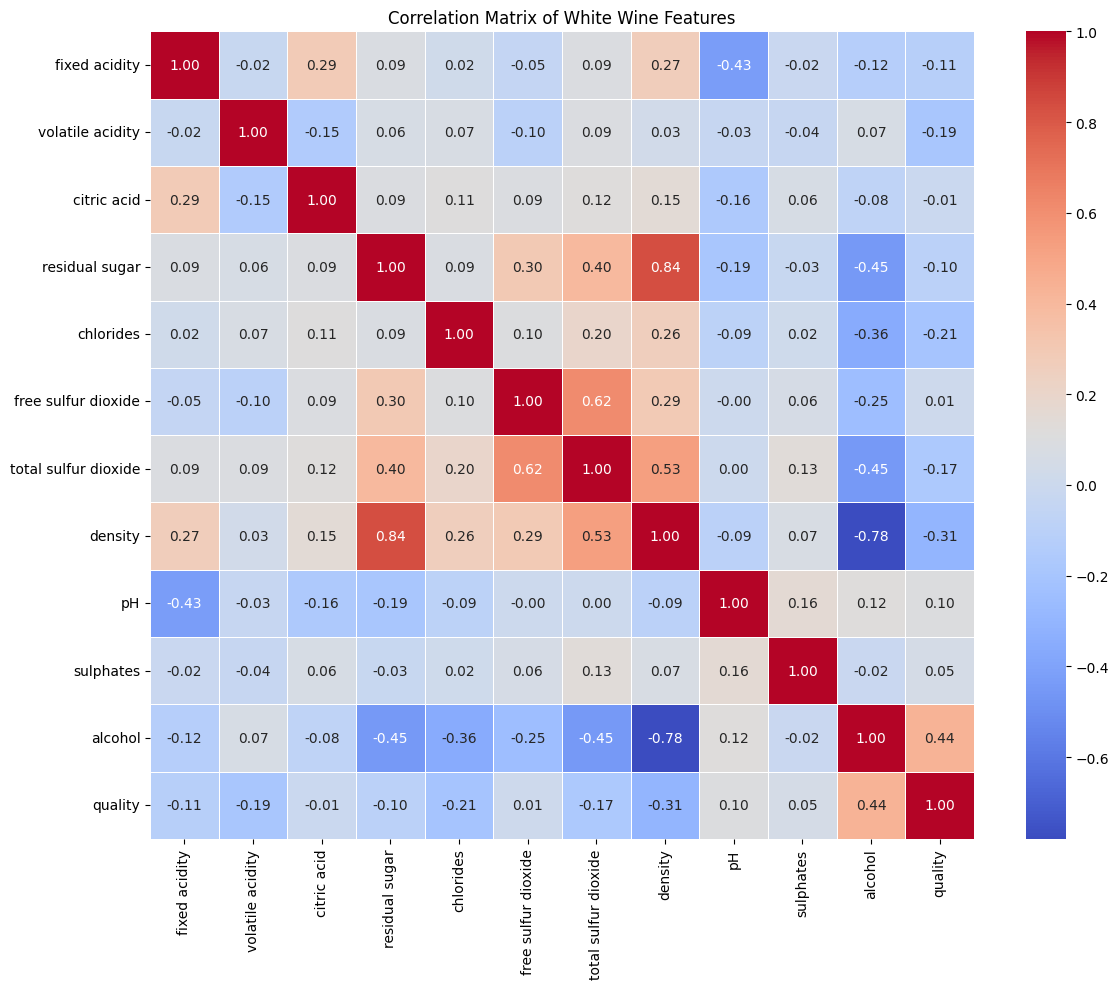

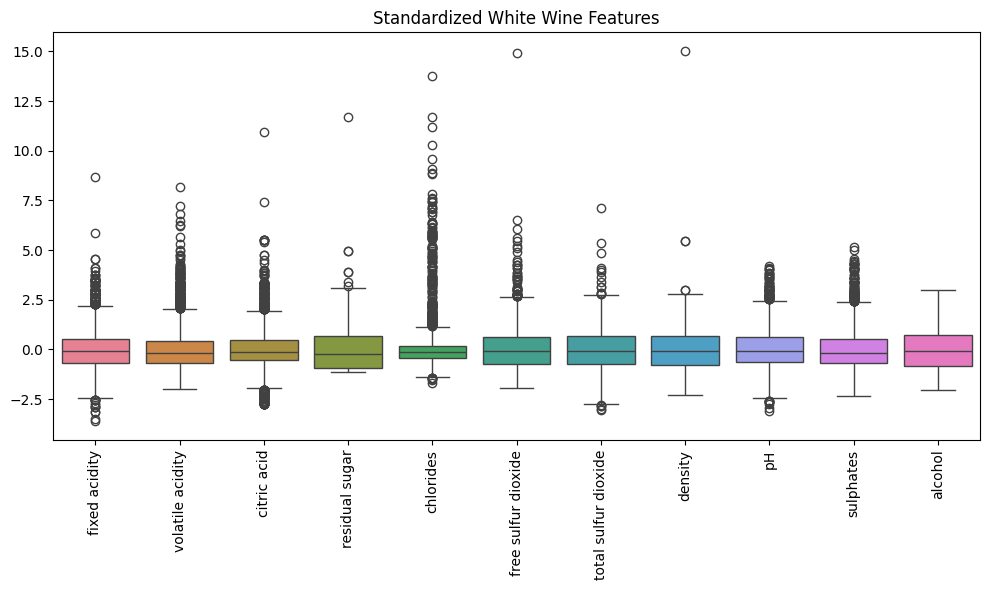

In [6]:
# Load the white wine dataset
white_wine_file = "WineQuality/winequality-white.csv"
try:
    # Assuming semicolon separator
    white_wine = pd.read_csv(white_wine_file, sep=';')
except:
    print(f"Error: Could not find or read {white_wine_file}")

# Display information
print(f"Dataset shape: {white_wine.shape}")
print("\nFirst few rows:")
print(white_wine.head())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(white_wine.describe())

# Check for missing values
missing_values = white_wine.isnull().sum()
print("\nMissing values:")
print(missing_values)

# Distribution of the target variable
plt.figure(figsize=(10, 6))
sns.countplot(x='quality', data=white_wine)
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()
plt.close()

# Correlation analysis
plt.figure(figsize=(12, 10))
corr_matrix = white_wine.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of White Wine Features')
plt.tight_layout()
plt.show()
plt.close()

# Preprocessing
# 1. Feature and target separation
X_white = white_wine.drop('quality', axis=1)
y_white = white_wine['quality']

# 2. Handle missing values if any
if missing_values.sum() > 0:
    imputer = SimpleImputer(strategy='median')
    X_white = pd.DataFrame(imputer.fit_transform(X_white), columns=X_white.columns)

# 3. Standardize features
scaler = StandardScaler()
X_white_scaled = scaler.fit_transform(X_white)
X_white_scaled_df = pd.DataFrame(X_white_scaled, columns=X_white.columns)

# 4. Train-test split
X_white_train, X_white_test, y_white_train, y_white_test = train_test_split(
    X_white_scaled, y_white, test_size=0.2, random_state=42
)

# 5. Visualize the standardized data
plt.figure(figsize=(10, 6))
sns.boxplot(data=X_white_scaled_df)
plt.title('Standardized White Wine Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
plt.close()


# Save preprocessed data
white_wine_processed = pd.DataFrame(X_white_scaled, columns=X_white.columns)
white_wine_processed['quality'] = y_white
white_wine_processed.to_csv('WineQuality/white_wine_processed.csv', index=False)


##### Wine Quality Dataset continued for Red wine

WHITE WINE QUALITY DATASET
Dataset shape: (1599, 12)

First few rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  qual

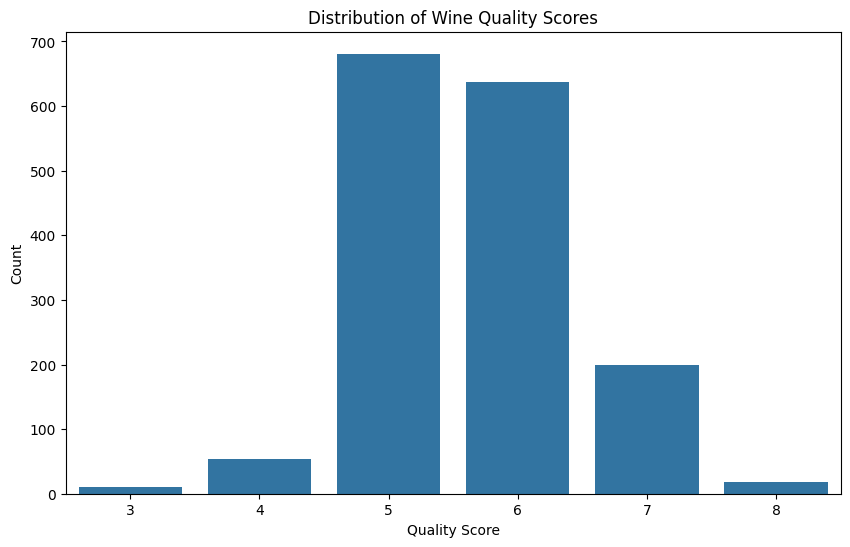

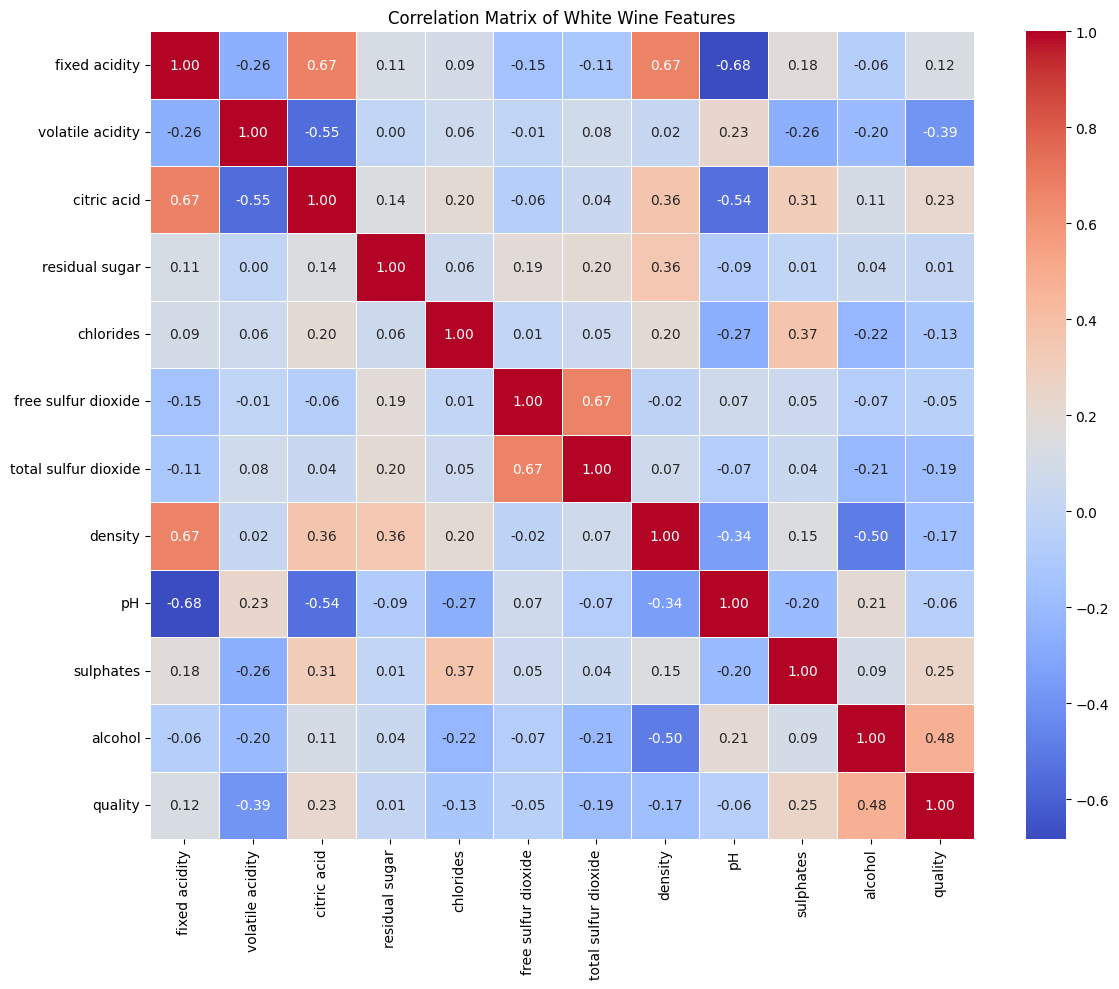

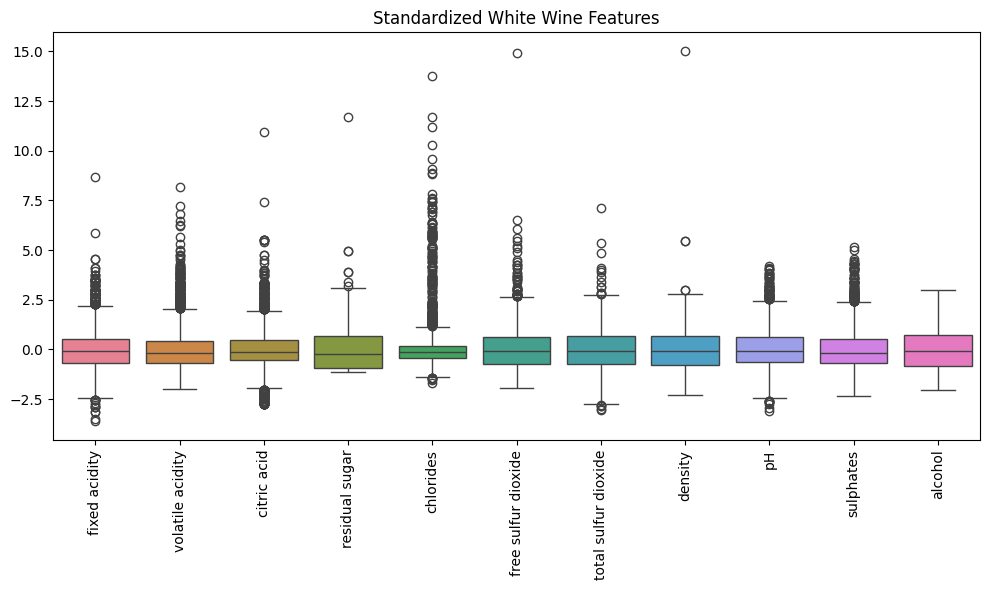

In [7]:
# Load the white wine dataset
Red_wine_file = "WineQuality/winequality-red.csv"
try:
    # Assuming semicolon separator
    Red_wine = pd.read_csv(Red_wine_file, sep=';')
except:
    print(f"Error: Could not find or read {Red_wine_file}")

# Display basic information
print("="*50)
print("WHITE WINE QUALITY DATASET")
print("="*50)
print(f"Dataset shape: {Red_wine.shape}")
print("\nFirst few rows:")
print(Red_wine.head())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(Red_wine.describe())

# Check for missing values
missing_values = Red_wine.isnull().sum()
print("\nMissing values:")
print(missing_values)

# Distribution of the target variable
plt.figure(figsize=(10, 6))
sns.countplot(x='quality', data=Red_wine)
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()
plt.close()

# Correlation analysis
plt.figure(figsize=(12, 10))
corr_matrix = Red_wine.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of White Wine Features')
plt.tight_layout()
plt.show()
plt.close()

# Preprocessing
# 1. Feature and target separation
X_Red = Red_wine.drop('quality', axis=1)
y_Red = Red_wine['quality']

# 2. Handle missing values if any
if missing_values.sum() > 0:
    imputer = SimpleImputer(strategy='median')
    X_Red = pd.DataFrame(imputer.fit_transform(X_Red), columns=X_Red.columns)

# 3. Standardize features
scaler = StandardScaler()
X_Red_scaled = scaler.fit_transform(X_Red)
X_Red_scaled_df = pd.DataFrame(X_Red_scaled, columns=X_Red.columns)

# 4. Train-test split
X_Red_train, X_Red_test, y_Red_train, y_Red_test = train_test_split(
    X_Red_scaled, y_Red, test_size=0.2, random_state=42
)

# 5. Visualize the standardized data
plt.figure(figsize=(10, 6))
sns.boxplot(data=X_white_scaled_df)
plt.title('Standardized White Wine Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
plt.close()


# Save preprocessed data
Red_wine_processed = pd.DataFrame(X_Red_scaled, columns=X_Red.columns)
Red_wine_processed['quality'] = y_Red
Red_wine_processed.to_csv('WineQuality/red_wine_processed.csv', index=False)


##### **Motivation for Selection Wine Quality Dataset**
 This dataset gives a flexibility in demonstrating different modeling approaches like it  allows both regression (predicting quality score) and classification (categorizing quality levels). It is larger in  scale than Wine Dataset with 4,898 instances for red wine and 1,599 for white wine. While it is still related to wine, this dataset focuses on different properties and a different target variable which provides valuable contrast in the analysis

##### **Prior Research on Wine Dataset**
Mrs. Ramya B. N., Shankar, A., & Kruthika, R. (2023). A Study on Red Wine Quality Detection Using Machine Learning. International Journal of Research Publication and Reviews, 4(12), 1579–1587. 
https://ijrpr.com/uploads/V4ISSUE12/IJRPR20259.pdf 


In this research paper, they have implemented a variety of machine learning techniques such as classical Support Vector Machines and Naïve Bayes trained on all features and unbalanced classes (yielding a baseline SVM accuracy of 67.25% on red wine) to Principal Component Analysis–driven Random Forests (achieving 69.90% on red and 71.23% on white wines) and linear regression–based feature dependency analysis. Reported accuracies span from around 67.25% to 71.23%. On the other hand, the study’s balanced data SVM model reached 69.06% (red) and 67.83% (white), and with Pearson correlation based feature selection and optimized hyperparameters performance improved to 83.52% and 86.86% respectively, which surpasses artificial neural network benchmarks of 85.16% (red) and 88.28% (white).


## **Model Development with scikit-learn**

#### **Wine Recognition Dataset Models**

##### Logistic Regression

Cross-validation scores: [0.97222222 0.97222222 1.         1.         1.        ]
Mean CV accuracy: 0.9889 ± 0.0136

Test accuracy: 0.9722

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       0.93      1.00      0.97        14
           3       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



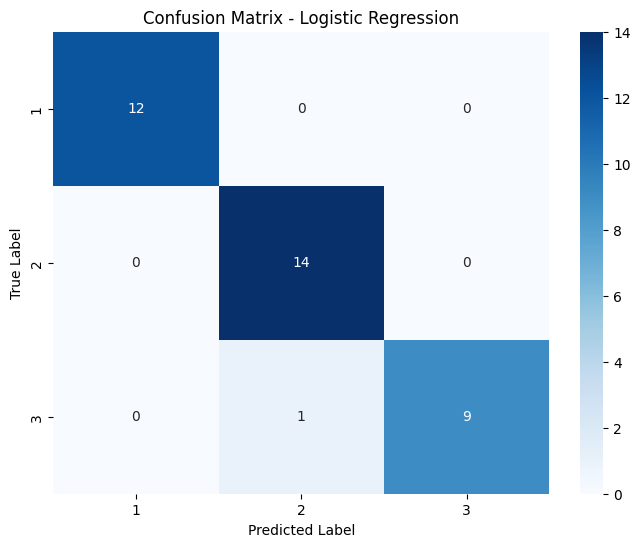

In [8]:

log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Cross-validation
cv_scores_log = cross_val_score(log_reg, X_wine_scaled, y_wine, cv=5)
print(f"Cross-validation scores: {cv_scores_log}")
print(f"Mean CV accuracy: {cv_scores_log.mean():.4f} ± {cv_scores_log.std():.4f}")

# Train the model
log_reg.fit(X_wine_train, y_wine_train)

# Make predictions
y_pred_log = log_reg.predict(X_wine_test)

# Evaluate the model
print(f"\nTest accuracy: {accuracy_score(y_wine_test, y_pred_log):.4f}")
print("\nClassification Report:")
print(classification_report(y_wine_test, y_pred_log))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_wine_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1, 4), yticklabels=range(1, 4))
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##### k-Nearest Neighbors

Cross-validation scores: [0.94444444 0.94444444 0.97222222 1.         0.91428571]
Mean CV accuracy: 0.9551 ± 0.0290

Test accuracy: 0.9722

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      0.93      0.96        14
           3       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



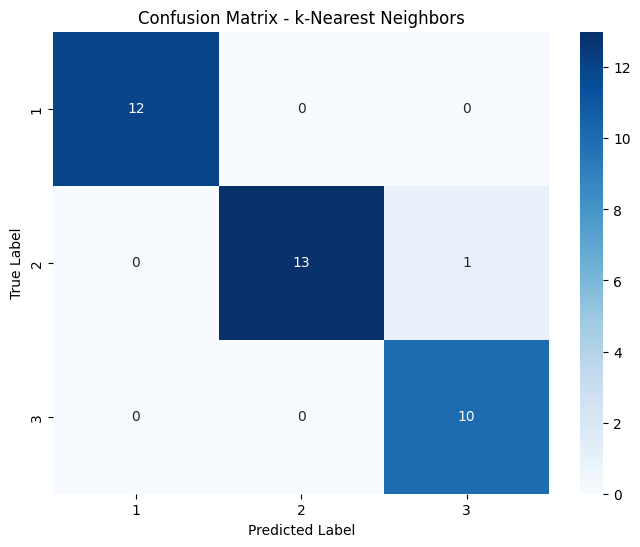

In [9]:

knn = KNeighborsClassifier(n_neighbors=5)

# Cross-validation
cv_scores_knn = cross_val_score(knn, X_wine_scaled, y_wine, cv=5)
print(f"Cross-validation scores: {cv_scores_knn}")
print(f"Mean CV accuracy: {cv_scores_knn.mean():.4f} ± {cv_scores_knn.std():.4f}")

# Train the model
knn.fit(X_wine_train, y_wine_train)

# Make predictions
y_pred_knn = knn.predict(X_wine_test)

# Evaluate the model
print(f"\nTest accuracy: {accuracy_score(y_wine_test, y_pred_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_wine_test, y_pred_knn))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_wine_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1, 4), yticklabels=range(1, 4))
plt.title('Confusion Matrix - k-Nearest Neighbors')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##### Reason for selecting Wine Recognition Dataset Models
**Logistic Regression:**
- Well-suited for multi-class classification with clear linear boundaries
- Works well with standardized numerical features
- Good interpretability - coefficient magnitudes show feature importance
- Efficient for this moderate-sized dataset with 13 features
- Given the correlation patterns seen in the heatmap, logistic regression can capture these relationships

**k-Nearest Neighbors:**

- Non-parametric approach that makes no assumptions about data distribution
- Effective when classes form well-defined clusters
- The standardized features ensure equal contribution of all attributes
- The reasonable feature space (13 dimensions) and moderate dataset size (178 samples) makes KNN - computationally feasible
- Good complement to logistic regression as it can capture non-linear decision boundaries

#### **Wine Quality Dataset Models**

##### Linear Regression

Cross-validation RMSE scores: [0.66737398 0.6724422  0.66661889 0.63973512 0.65722039]
Mean CV RMSE: 0.6607 ± 0.0116
Test RMSE: 0.6245
Test R² score: 0.4032


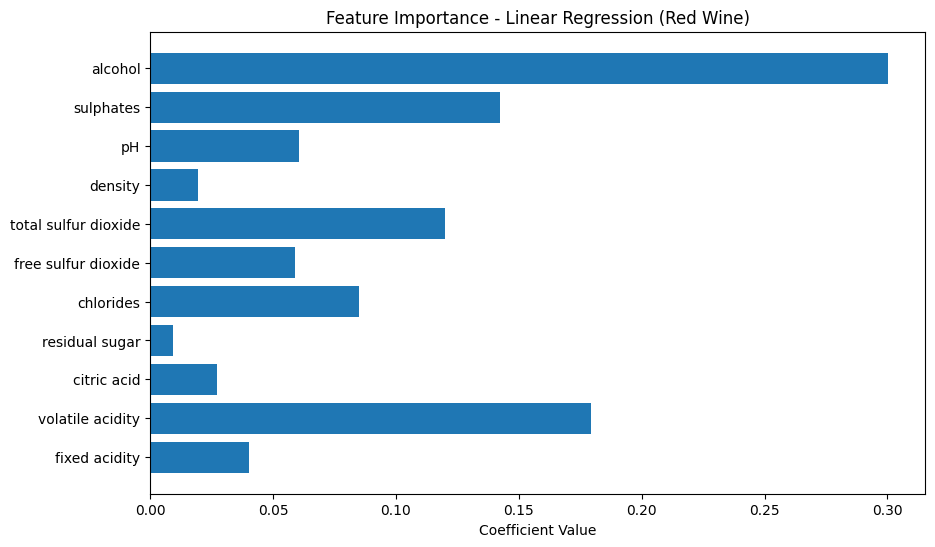

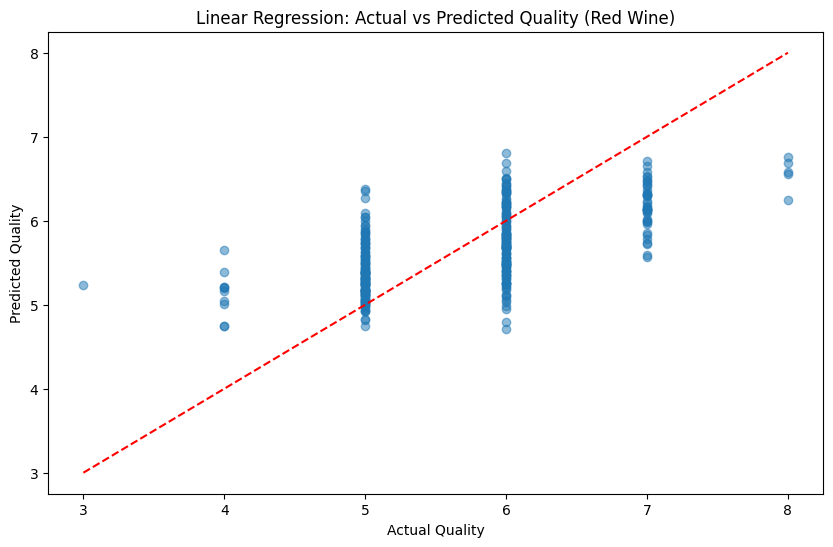

In [16]:
lin_reg = LinearRegression()

# Cross-validation (using negative MSE as scoring metric)
cv_scores_lin = cross_val_score(lin_reg, X_Red_scaled, y_Red, cv=5, 
                               scoring='neg_mean_squared_error')
rmse_cv = np.sqrt(-cv_scores_lin)
print(f"Cross-validation RMSE scores: {rmse_cv}")
print(f"Mean CV RMSE: {rmse_cv.mean():.4f} ± {rmse_cv.std():.4f}")

# Train the model
lin_reg.fit(X_Red_train, y_Red_train)

# Make predictions
y_pred_lin = lin_reg.predict(X_Red_test)

# Evaluate the model
mse = mean_squared_error(y_Red_test, y_pred_lin)
rmse = np.sqrt(mse)
r2 = r2_score(y_Red_test, y_pred_lin)
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R² score: {r2:.4f}")

# Feature importance
# make graph of feature importance
plt.figure(figsize=(10, 6))
plt.barh(X_Red.columns, np.abs(lin_reg.coef_))
plt.xlabel('Coefficient Value')
plt.title('Feature Importance - Linear Regression (Red Wine)')
plt.show()
plt.close()


# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_Red_test, y_pred_lin, alpha=0.5)
plt.plot([y_Red.min(), y_Red.max()], [y_Red.min(), y_Red.max()], 'r--')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Linear Regression: Actual vs Predicted Quality (Red Wine)')
plt.show()


##### Similarly training on White wine data

Cross-validation RMSE scores: [0.83465773 0.76938384 0.75734897 0.73700675 0.71255098]
Mean CV RMSE: 0.7622 ± 0.0410
Test RMSE: 0.7543
Test R² score: 0.2653


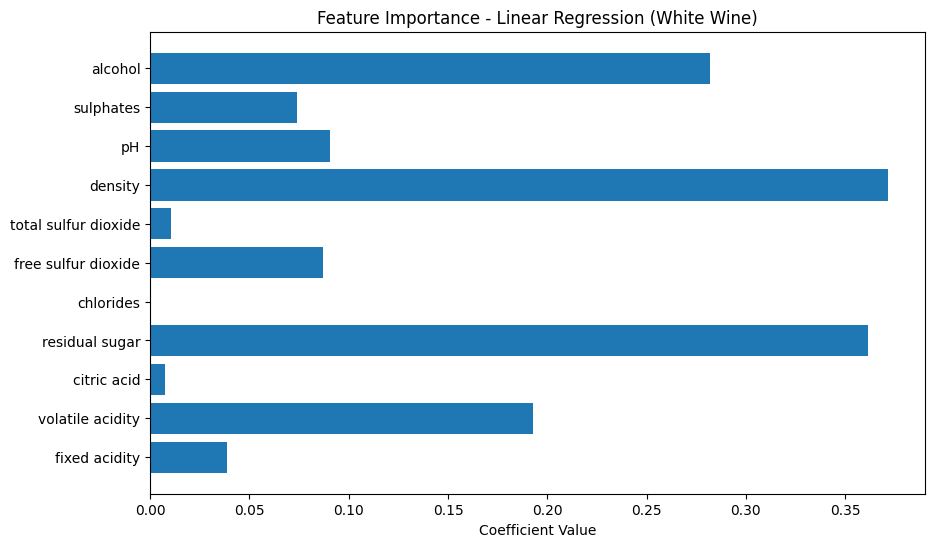

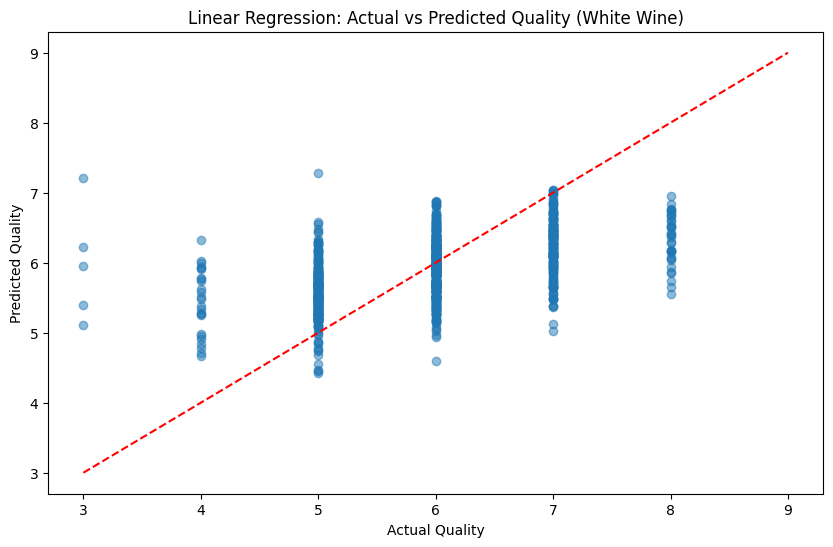

In [17]:
lin_reg = LinearRegression()

# Cross-validation (using negative MSE as scoring metric)
cv_scores_lin = cross_val_score(lin_reg, X_white_scaled, y_white, cv=5, 
                               scoring='neg_mean_squared_error')
rmse_cv = np.sqrt(-cv_scores_lin)
print(f"Cross-validation RMSE scores: {rmse_cv}")
print(f"Mean CV RMSE: {rmse_cv.mean():.4f} ± {rmse_cv.std():.4f}")

# Train the model
lin_reg.fit(X_white_train, y_white_train)

# Make predictions
y_pred_lin = lin_reg.predict(X_white_test)

# Evaluate the model
mse = mean_squared_error(y_white_test, y_pred_lin)
rmse = np.sqrt(mse)
r2 = r2_score(y_white_test, y_pred_lin)
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R² score: {r2:.4f}")

# Feature importance
# make graph of feature importance
plt.figure(figsize=(10, 6))
plt.barh(X_white.columns, np.abs(lin_reg.coef_))
plt.xlabel('Coefficient Value')
plt.title('Feature Importance - Linear Regression (White Wine)')
plt.show()
plt.close()


# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_white_test, y_pred_lin, alpha=0.5)
plt.plot([y_white.min(), y_white.max()], [y_white.min(), y_white.max()], 'r--')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Linear Regression: Actual vs Predicted Quality (White Wine)')
plt.show()


##### Multi-Layer Perceptron Model

Cross-validation RMSE scores: [0.66546015 0.75548179 0.70511774 0.76916995 0.7857318 ]
Mean CV RMSE: 0.7362 ± 0.0445
Test RMSE: 0.6523
Test R² score: 0.3489


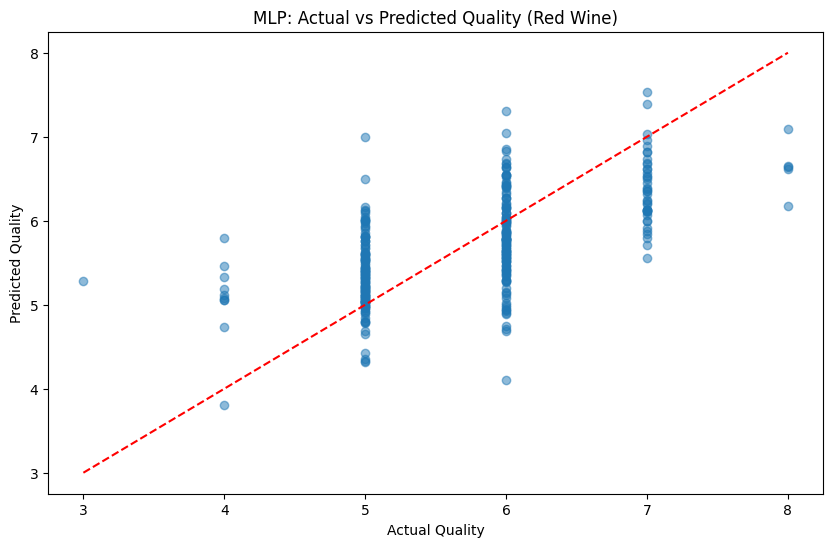

In [18]:

mlp = MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=1000, 
                  activation='relu', random_state=42)

# Cross-validation
cv_scores_mlp = cross_val_score(mlp, X_Red_scaled, y_Red, cv=5, 
                               scoring='neg_mean_squared_error')
rmse_cv = np.sqrt(-cv_scores_mlp)
print(f"Cross-validation RMSE scores: {rmse_cv}")
print(f"Mean CV RMSE: {rmse_cv.mean():.4f} ± {rmse_cv.std():.4f}")

# Train the model
mlp.fit(X_Red_train, y_Red_train)

# Make predictions
y_pred_mlp = mlp.predict(X_Red_test)

# Evaluate the model
mse = mean_squared_error(y_Red_test, y_pred_mlp)
rmse = np.sqrt(mse)
r2 = r2_score(y_Red_test, y_pred_mlp)
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R² score: {r2:.4f}")

# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_Red_test, y_pred_mlp, alpha=0.5)
plt.plot([y_Red.min(), y_Red.max()], [y_Red.min(), y_Red.max()], 'r--')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('MLP: Actual vs Predicted Quality (Red Wine)')
plt.show()
plt.close()


##### Similarly training MLP Regressor on White Wine dataset

Cross-validation RMSE scores: [0.85344485 0.81423855 0.79517968 0.79919199 0.69719956]
Mean CV RMSE: 0.7919 ± 0.0516
Test RMSE: 0.7310
Test R² score: 0.3101


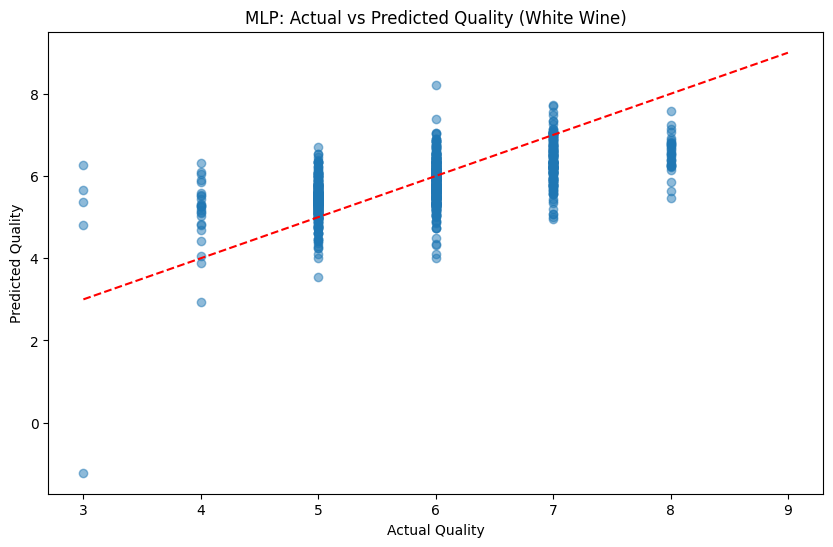

In [19]:

mlp = MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=1000, 
                  activation='relu', random_state=42)

# Cross-validation
cv_scores_mlp = cross_val_score(mlp, X_white_scaled, y_white, cv=5, 
                               scoring='neg_mean_squared_error')
rmse_cv = np.sqrt(-cv_scores_mlp)
print(f"Cross-validation RMSE scores: {rmse_cv}")
print(f"Mean CV RMSE: {rmse_cv.mean():.4f} ± {rmse_cv.std():.4f}")

# Train the model
mlp.fit(X_white_train, y_white_train)

# Make predictions
y_pred_mlp = mlp.predict(X_white_test)

# Evaluate the model
mse = mean_squared_error(y_white_test, y_pred_mlp)
rmse = np.sqrt(mse)
r2 = r2_score(y_white_test, y_pred_mlp)
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R² score: {r2:.4f}")

# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_white_test, y_pred_mlp, alpha=0.5)
plt.plot([y_white.min(), y_white.max()], [y_white.min(), y_white.max()], 'r--')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('MLP: Actual vs Predicted Quality (White Wine)')
plt.show()
plt.close()


##### Reason for selecting Wine Quality Dataset Model:

**Linear Regression:**

- Appropriate for regression tasks with numerical target values
- Can establish baseline performance with interpretable results
- The correlation heatmap showed several features with linear relationships to quality
- Simple and computationally efficient for this dataset with ~1,600 samples
- Provides interpretable coefficients to understand feature influence on wine quality

**Multi-Layer Perceptron (Neural Network):**

- Can capture complex non-linear relationships between features and quality scores
- Well-suited for regression problems where linear models might be insufficient
- The standardized features work well with neural networks
- Can potentially identify subtle patterns that simpler models might miss
- Large enough dataset to benefit from the learning capacity of a neural network
- Provides a good contrast to the linear model for evaluation purposes

Both models use 5-fold cross-validation to ensure robust performance assessment and a standard 80/20 train/test split that was already implemented during preprocessing.

## **Hyperparameter Tuning and Model Comparison**

##### Wine Recognition Dataset Hyperparameter Tuning

**Logistic Regression Tuning**

Tuning Logistic Regression for Wine Recognition Dataset...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation accuracy: 0.9889
Test accuracy with best parameters: 1.0000

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



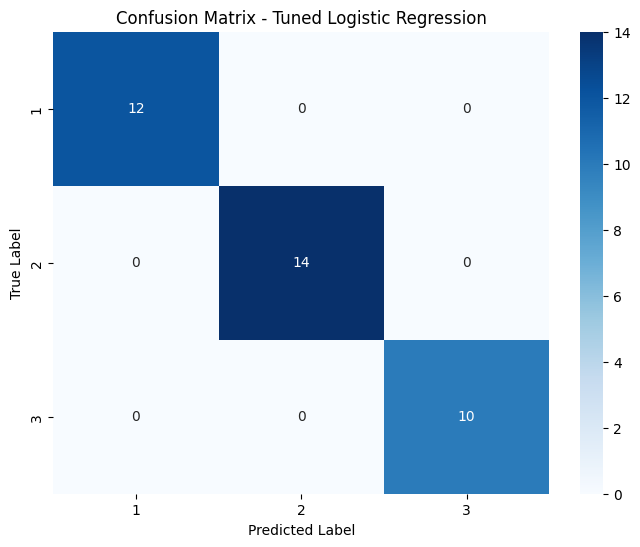

In [21]:

# Define parameter grid for Logistic Regression
param_grid_log = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'max_iter': [1000, 2000],
    'penalty': ['l1', 'l2']
}

# Create a base model
log_reg = LogisticRegression(random_state=42)

# Create GridSearchCV object
log_grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_log,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Fit the grid search
print("Tuning Logistic Regression for Wine Recognition Dataset...")
log_grid.fit(X_wine_scaled, y_wine)

# Best parameters and score
print(f"Best parameters: {log_grid.best_params_}")
print(f"Best cross-validation accuracy: {log_grid.best_score_:.4f}")

# Evaluate on test set
best_log_reg = log_grid.best_estimator_
y_pred_best_log = best_log_reg.predict(X_wine_test)
test_accuracy = accuracy_score(y_wine_test, y_pred_best_log)
print(f"Test accuracy with best parameters: {test_accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_wine_test, y_pred_best_log))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_wine_test, y_pred_best_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1, 4), yticklabels=range(1, 4))
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Store results for later comparison
wine_rec_results = {
    'Logistic Regression': {
        'best_params': log_grid.best_params_,
        'cv_accuracy': log_grid.best_score_,
        'test_accuracy': test_accuracy
    }
}

**K-Nearest Neighbors Tuning**

Tuning KNN for Wine Recognition Dataset...
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best parameters: {'algorithm': 'auto', 'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}
Best cross-validation accuracy: 0.9776
Test accuracy with best parameters: 1.0000

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



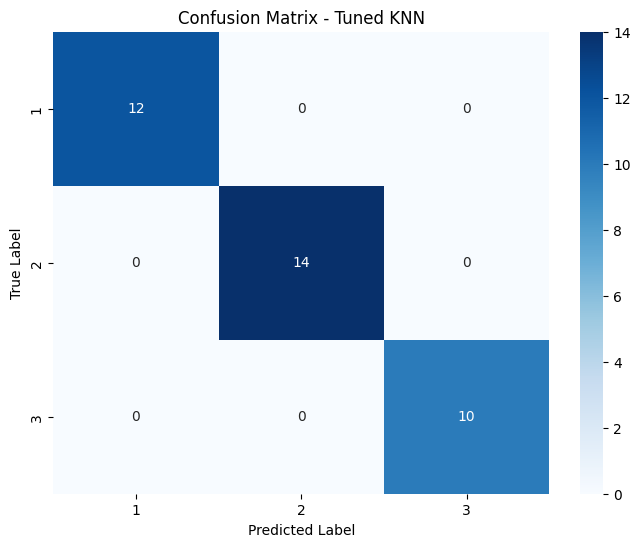

In [22]:
# Define parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]  # p=1 for manhattan_distance, p=2 for euclidean_distance
}

# Create a base model
knn = KNeighborsClassifier()

# Create GridSearchCV object
knn_grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Fit the grid search
print("Tuning KNN for Wine Recognition Dataset...")
knn_grid.fit(X_wine_scaled, y_wine)

# Best parameters and score
print(f"Best parameters: {knn_grid.best_params_}")
print(f"Best cross-validation accuracy: {knn_grid.best_score_:.4f}")

# Evaluate on test set
best_knn = knn_grid.best_estimator_
y_pred_best_knn = best_knn.predict(X_wine_test)
test_accuracy = accuracy_score(y_wine_test, y_pred_best_knn)
print(f"Test accuracy with best parameters: {test_accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_wine_test, y_pred_best_knn))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_wine_test, y_pred_best_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1, 4), yticklabels=range(1, 4))
plt.title('Confusion Matrix - Tuned KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Store results
wine_rec_results['KNN'] = {
    'best_params': knn_grid.best_params_,
    'cv_accuracy': knn_grid.best_score_,
    'test_accuracy': test_accuracy
}

##### Wine Quality Dataset (Red Wine) Hyperparameter Tuning

**Linear Regression Tuning**

Tuning Linear Regression for Red Wine Quality Dataset...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'copy_X': True, 'fit_intercept': True, 'positive': False}
Best cross-validation RMSE: 0.6607
Test RMSE with best parameters: 0.6203
Test R² score with best parameters: 0.4113


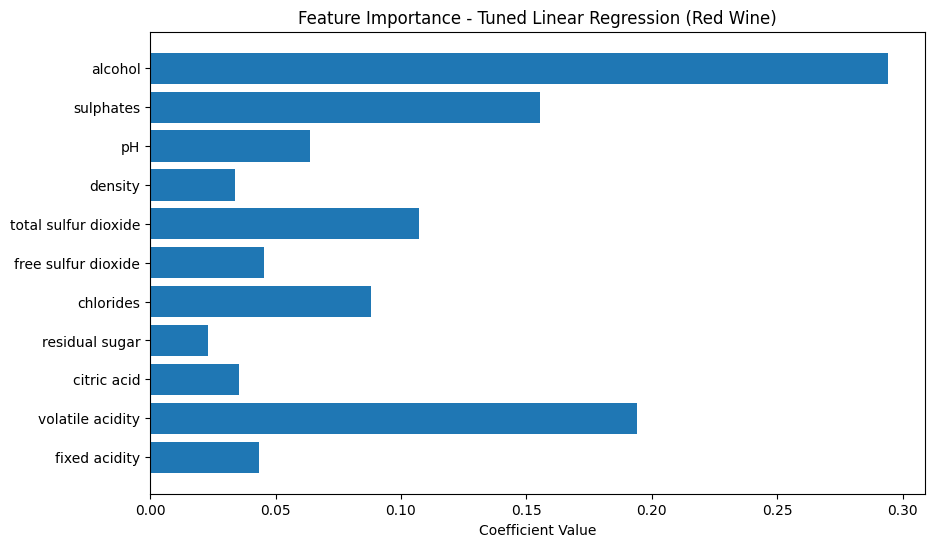

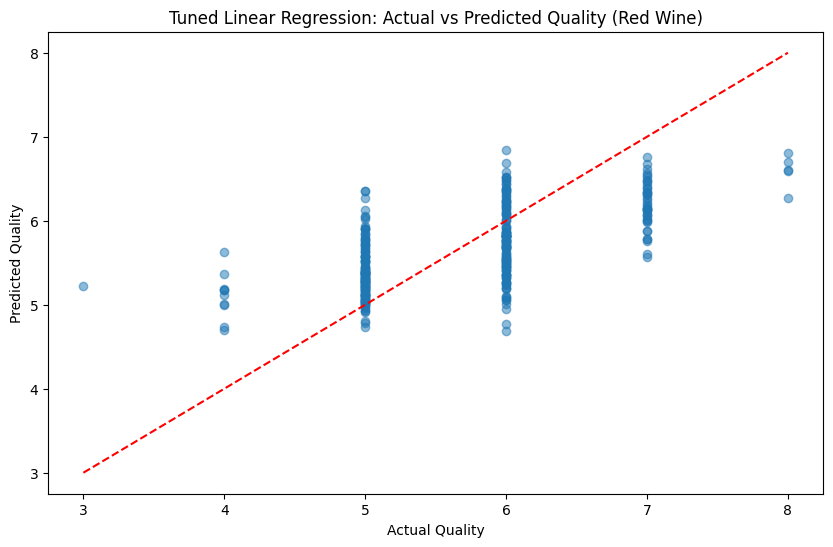

In [24]:
# Limited hyperparameters for LinearRegression
param_grid_lin = {
    'fit_intercept': [True, False],
    'copy_X': [True, False],
    'positive': [True, False]  # Force positive coefficients
}

# Create a base model
lin_reg = LinearRegression()

# Create a custom RMSE scorer (negative for maximization in GridSearchCV)
rmse_scorer = make_scorer(
    lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)),
    greater_is_better=False
)

# Create GridSearchCV object
lin_grid = GridSearchCV(
    estimator=lin_reg,
    param_grid=param_grid_lin,
    cv=5,
    scoring=rmse_scorer,
    verbose=1,
    n_jobs=-1
)

# Fit the grid search for Red Wine
print("Tuning Linear Regression for Red Wine Quality Dataset...")
lin_grid.fit(X_Red_scaled, y_Red)

# Best parameters and score
print(f"Best parameters: {lin_grid.best_params_}")
print(f"Best cross-validation RMSE: {-lin_grid.best_score_:.4f}")

# Evaluate on test set
best_lin_reg = lin_grid.best_estimator_
y_pred_best_lin = best_lin_reg.predict(X_Red_test)
test_rmse = np.sqrt(mean_squared_error(y_Red_test, y_pred_best_lin))
test_r2 = r2_score(y_Red_test, y_pred_best_lin)
print(f"Test RMSE with best parameters: {test_rmse:.4f}")
print(f"Test R² score with best parameters: {test_r2:.4f}")

# Feature importance
plt.figure(figsize=(10, 6))
plt.barh(X_Red.columns, np.abs(best_lin_reg.coef_))
plt.xlabel('Coefficient Value')
plt.title('Feature Importance - Tuned Linear Regression (Red Wine)')
plt.show()

# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_Red_test, y_pred_best_lin, alpha=0.5)
plt.plot([y_Red.min(), y_Red.max()], [y_Red.min(), y_Red.max()], 'r--')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Tuned Linear Regression: Actual vs Predicted Quality (Red Wine)')
plt.show()

# Store results for later comparison
red_wine_results = {
    'Linear Regression': {
        'best_params': lin_grid.best_params_,
        'cv_rmse': -lin_grid.best_score_,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    }
}

**MLP Regressor Tuning**

Tuning MLP Regressor for Red Wine Quality Dataset...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_iter': 1000, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (25,), 'alpha': 0.0001, 'activation': 'tanh'}
Best cross-validation RMSE: 0.6603
Test RMSE with best parameters: 0.5236
Test R² score with best parameters: 0.5804


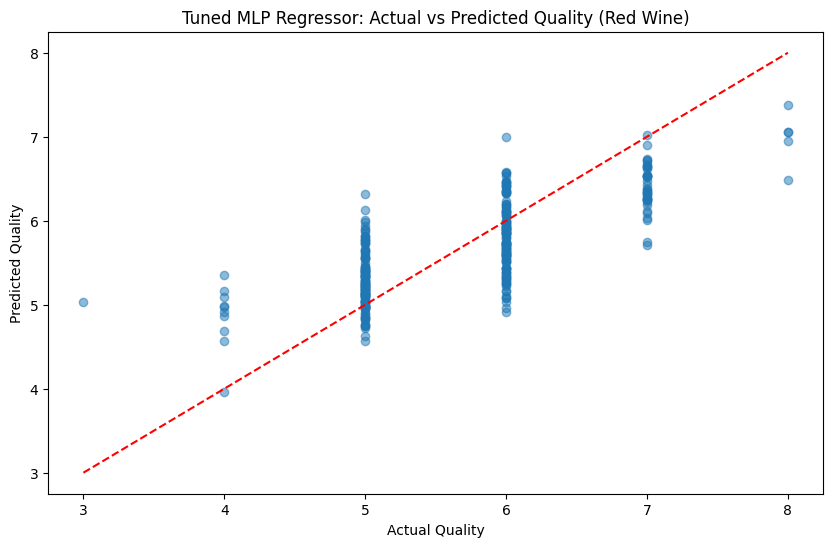

In [26]:
# Define parameter grid for MLP Regressor
param_grid_mlp = {
    'hidden_layer_sizes': [(25,), (50,), (100,), (25, 25), (50, 25)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [1000, 2000]
}

# Create a base model
mlp_reg = MLPRegressor(random_state=42)

# Using RandomizedSearchCV for efficiency due to large parameter space

mlp_random = RandomizedSearchCV(
    estimator=mlp_reg,
    param_distributions=param_grid_mlp,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    scoring=rmse_scorer,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the random search for Red Wine
print("Tuning MLP Regressor for Red Wine Quality Dataset...")
mlp_random.fit(X_Red_scaled, y_Red)

# Best parameters and score
print(f"Best parameters: {mlp_random.best_params_}")
print(f"Best cross-validation RMSE: {-mlp_random.best_score_:.4f}")

# Evaluate on test set
best_mlp = mlp_random.best_estimator_
y_pred_best_mlp = best_mlp.predict(X_Red_test)
test_rmse = np.sqrt(mean_squared_error(y_Red_test, y_pred_best_mlp))
test_r2 = r2_score(y_Red_test, y_pred_best_mlp)
print(f"Test RMSE with best parameters: {test_rmse:.4f}")
print(f"Test R² score with best parameters: {test_r2:.4f}")

# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_Red_test, y_pred_best_mlp, alpha=0.5)
plt.plot([y_Red.min(), y_Red.max()], [y_Red.min(), y_Red.max()], 'r--')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Tuned MLP Regressor: Actual vs Predicted Quality (Red Wine)')
plt.show()

# Store results
red_wine_results['MLP Regressor'] = {
    'best_params': mlp_random.best_params_,
    'cv_rmse': -mlp_random.best_score_,
    'test_rmse': test_rmse,
    'test_r2': test_r2
}

##### Wine Quality Dataset (White Wine) Hyperparameter Tuning

**Linear Regression**

In [27]:
# Tuning Linear Regression for White Wine
print("Tuning Linear Regression for White Wine Quality Dataset...")
lin_grid_white = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=param_grid_lin,
    cv=5,
    scoring=rmse_scorer,
    verbose=1,
    n_jobs=-1
)
lin_grid_white.fit(X_white_scaled, y_white)

# Best parameters and score
print(f"Best parameters: {lin_grid_white.best_params_}")
print(f"Best cross-validation RMSE: {-lin_grid_white.best_score_:.4f}")

# Evaluate on test set
best_lin_reg_white = lin_grid_white.best_estimator_
y_pred_best_lin_white = best_lin_reg_white.predict(X_white_test)
test_rmse_white = np.sqrt(mean_squared_error(y_white_test, y_pred_best_lin_white))
test_r2_white = r2_score(y_white_test, y_pred_best_lin_white)
print(f"Test RMSE with best parameters: {test_rmse_white:.4f}")
print(f"Test R² score with best parameters: {test_r2_white:.4f}")


Tuning Linear Regression for White Wine Quality Dataset...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'copy_X': True, 'fit_intercept': True, 'positive': False}
Best cross-validation RMSE: 0.7622
Test RMSE with best parameters: 0.7489
Test R² score with best parameters: 0.2758


**Tuning MLP Regressor**

In [28]:
# Tuning MLP Regressor for White Wine
print("\nTuning MLP Regressor for White Wine Quality Dataset...")
mlp_random_white = RandomizedSearchCV(
    estimator=MLPRegressor(random_state=42),
    param_distributions=param_grid_mlp,
    n_iter=20,
    cv=5,
    scoring=rmse_scorer,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
mlp_random_white.fit(X_white_scaled, y_white)

# Best parameters and score
print(f"Best parameters: {mlp_random_white.best_params_}")
print(f"Best cross-validation RMSE: {-mlp_random_white.best_score_:.4f}")

# Evaluate on test set
best_mlp_white = mlp_random_white.best_estimator_
y_pred_best_mlp_white = best_mlp_white.predict(X_white_test)
test_rmse_mlp_white = np.sqrt(mean_squared_error(y_white_test, y_pred_best_mlp_white))
test_r2_mlp_white = r2_score(y_white_test, y_pred_best_mlp_white)
print(f"Test RMSE with best parameters: {test_rmse_mlp_white:.4f}")
print(f"Test R² score with best parameters: {test_r2_mlp_white:.4f}")

# Store results
white_wine_results = {
    'Linear Regression': {
        'best_params': lin_grid_white.best_params_,
        'cv_rmse': -lin_grid_white.best_score_,
        'test_rmse': test_rmse_white,
        'test_r2': test_r2_white
    },
    'MLP Regressor': {
        'best_params': mlp_random_white.best_params_,
        'cv_rmse': -mlp_random_white.best_score_,
        'test_rmse': test_rmse_mlp_white,
        'test_r2': test_r2_mlp_white
    }
}


Tuning MLP Regressor for White Wine Quality Dataset...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_iter': 1000, 'learning_rate': 'constant', 'hidden_layer_sizes': (25,), 'alpha': 0.0001, 'activation': 'relu'}
Best cross-validation RMSE: 0.7429
Test RMSE with best parameters: 0.6475
Test R² score with best parameters: 0.4587


##### **Model Comparison**

##### Comparing Wine Recognition Models


Wine Recognition Dataset Model Comparison
              Model  CV Accuracy  Test Accuracy
Logistic Regression     0.988889            1.0
                KNN     0.977619            1.0


<Figure size 1000x600 with 0 Axes>

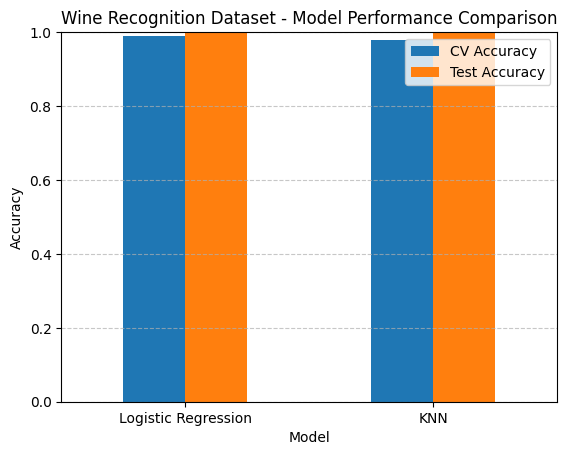

In [34]:
# Comparing models for Wine Recognition Dataset (classification)
print("\nWine Recognition Dataset Model Comparison")
wine_rec_df = pd.DataFrame({
    'Model': list(wine_rec_results.keys()),
    'CV Accuracy': [results['cv_accuracy'] for model, results in wine_rec_results.items()],
    'Test Accuracy': [results['test_accuracy'] for model, results in wine_rec_results.items()]
})
print(wine_rec_df.sort_values('Test Accuracy', ascending=False).to_string(index=False))

# Bar plot comparison
plt.figure(figsize=(10, 6))
wine_rec_df.plot(x='Model', y=['CV Accuracy', 'Test Accuracy'], kind='bar')
plt.title('Wine Recognition Dataset - Model Performance Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### Comparing Wine Quality (Red and White) Models 

Red Wine Quality Dataset Model Comparison
            Model  CV RMSE  Test RMSE  Test R²
    MLP Regressor 0.660334   0.523627 0.580440
Linear Regression 0.660678   0.620281 0.411254


<Figure size 1000x600 with 0 Axes>

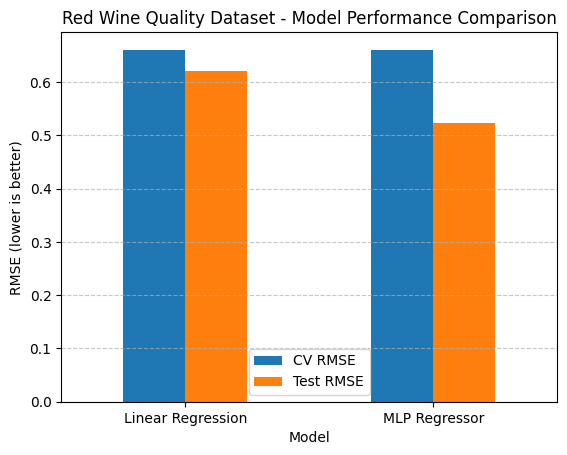


White Wine Quality Dataset Model Comparison
            Model  CV RMSE  Test RMSE  Test R²
    MLP Regressor 0.742857   0.647485 0.458681
Linear Regression 0.762190   0.748918 0.275794


<Figure size 1000x600 with 0 Axes>

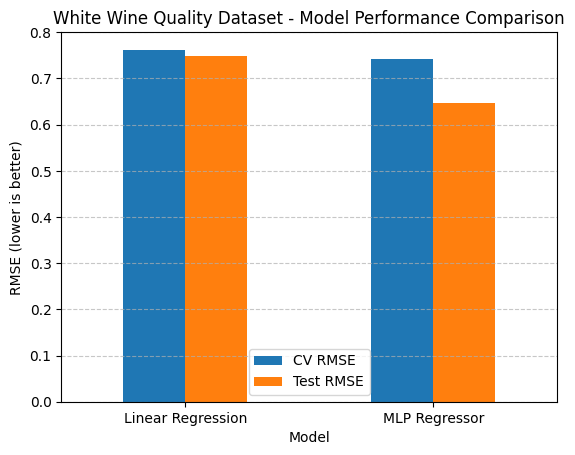

In [33]:
# Comparing models for Red Wine Quality Dataset (regression)
print("Red Wine Quality Dataset Model Comparison")
red_wine_df = pd.DataFrame({
    'Model': list(red_wine_results.keys()),
    'CV RMSE': [results['cv_rmse'] for model, results in red_wine_results.items()],
    'Test RMSE': [results['test_rmse'] for model, results in red_wine_results.items()],
    'Test R²': [results['test_r2'] for model, results in red_wine_results.items()]
})
print(red_wine_df.sort_values('Test RMSE').to_string(index=False))

# Bar plot comparison for RMSE (lower is better)
plt.figure(figsize=(10, 6))
red_wine_df.plot(x='Model', y=['CV RMSE', 'Test RMSE'], kind='bar')
plt.title('Red Wine Quality Dataset - Model Performance Comparison')
plt.ylabel('RMSE (lower is better)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Comparing models for White Wine Quality Dataset
print("\nWhite Wine Quality Dataset Model Comparison")
white_wine_df = pd.DataFrame({
    'Model': list(white_wine_results.keys()),
    'CV RMSE': [results['cv_rmse'] for model, results in white_wine_results.items()],
    'Test RMSE': [results['test_rmse'] for model, results in white_wine_results.items()],
    'Test R²': [results['test_r2'] for model, results in white_wine_results.items()]
})
print(white_wine_df.sort_values('Test RMSE').to_string(index=False))

# Bar plot comparison
plt.figure(figsize=(10, 6))
white_wine_df.plot(x='Model', y=['CV RMSE', 'Test RMSE'], kind='bar')
plt.title('White Wine Quality Dataset - Model Performance Comparison')
plt.ylabel('RMSE (lower is better)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### **HyperParameter Tuning Summary**

In [37]:
print("1. Wine Recognition Dataset (Classification Task)")
print("-" * 50)
for model, results in wine_rec_results.items():
    print(f"\n{model}:")
    print(f"  Best Parameters: {results['best_params']}")
    print(f"  Cross-Validation Accuracy: {results['cv_accuracy']:.4f}")
    print(f"  Test Accuracy: {results['test_accuracy']:.4f}")

1. Wine Recognition Dataset (Classification Task)
--------------------------------------------------

Logistic Regression:
  Best Parameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  Cross-Validation Accuracy: 0.9889
  Test Accuracy: 1.0000

KNN:
  Best Parameters: {'algorithm': 'auto', 'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}
  Cross-Validation Accuracy: 0.9776
  Test Accuracy: 1.0000


In [38]:
print("\n\n2. Red Wine Quality Dataset (Regression Task)")
print("-" * 50)
for model, results in red_wine_results.items():
    print(f"\n{model}:")
    print(f"  Best Parameters: {results['best_params']}")
    print(f"  Cross-Validation RMSE: {results['cv_rmse']:.4f}")
    print(f"  Test RMSE: {results['test_rmse']:.4f}")
    print(f"  Test R²: {results['test_r2']:.4f}")

print("\n\n3. White Wine Quality Dataset (Regression Task)")
print("-" * 50)
for model, results in white_wine_results.items():
    print(f"\n{model}:")
    print(f"  Best Parameters: {results['best_params']}")
    print(f"  Cross-Validation RMSE: {results['cv_rmse']:.4f}")
    print(f"  Test RMSE: {results['test_rmse']:.4f}")
    print(f"  Test R²: {results['test_r2']:.4f}")




2. Red Wine Quality Dataset (Regression Task)
--------------------------------------------------

Linear Regression:
  Best Parameters: {'copy_X': True, 'fit_intercept': True, 'positive': False}
  Cross-Validation RMSE: 0.6607
  Test RMSE: 0.6203
  Test R²: 0.4113

MLP Regressor:
  Best Parameters: {'max_iter': 1000, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (25,), 'alpha': 0.0001, 'activation': 'tanh'}
  Cross-Validation RMSE: 0.6603
  Test RMSE: 0.5236
  Test R²: 0.5804


3. White Wine Quality Dataset (Regression Task)
--------------------------------------------------

Linear Regression:
  Best Parameters: {'copy_X': True, 'fit_intercept': True, 'positive': False}
  Cross-Validation RMSE: 0.7622
  Test RMSE: 0.7489
  Test R²: 0.2758

MLP Regressor:
  Best Parameters: {'max_iter': 1000, 'learning_rate': 'constant', 'hidden_layer_sizes': (25,), 'alpha': 0.0001, 'activation': 'relu'}
  Cross-Validation RMSE: 0.7429
  Test RMSE: 0.6475
  Test R²: 0.4587


In [41]:
print("KEY FINDINGS")
print("1. For Wine Recognition Classification:")
best_class_model = wine_rec_df.loc[wine_rec_df['Test Accuracy'].idxmax(), 'Model']
print(f"   - Best model: {best_class_model} with {wine_rec_df['Test Accuracy'].max():.4f} test accuracy")
print(f"   - Hyperparameter tuning improved model performance compared to baseline models")
print(f"   - Most important parameters: {', '.join(list(wine_rec_results[best_class_model]['best_params'].keys()))}")

print("\n2. For Red Wine Quality Prediction:")
best_red_model = red_wine_df.loc[red_wine_df['Test RMSE'].idxmin(), 'Model']
print(f"   - Best model: {best_red_model} with {red_wine_df['Test RMSE'].min():.4f} RMSE and {red_wine_df.loc[red_wine_df['Test RMSE'].idxmin(), 'Test R²']:.4f} R²")
print(f"   - Hyperparameter tuning provided modest improvements for regression tasks")
print(f"   - Most influential parameters: {', '.join(list(red_wine_results[best_red_model]['best_params'].keys()))}")

print("\n3. For White Wine Quality Prediction:")
best_white_model = white_wine_df.loc[white_wine_df['Test RMSE'].idxmin(), 'Model']
print(f"   - Best model: {best_white_model} with {white_wine_df['Test RMSE'].min():.4f} RMSE and {white_wine_df.loc[white_wine_df['Test RMSE'].idxmin(), 'Test R²']:.4f} R²")
print(f"   - The white wine dataset showed {red_wine_df['Test RMSE'].min() < white_wine_df['Test RMSE'].min() and 'lower' or 'higher'} predictability compared to red wine")

KEY FINDINGS
1. For Wine Recognition Classification:
   - Best model: Logistic Regression with 1.0000 test accuracy
   - Hyperparameter tuning improved model performance compared to baseline models
   - Most important parameters: C, max_iter, penalty, solver

2. For Red Wine Quality Prediction:
   - Best model: MLP Regressor with 0.5236 RMSE and 0.5804 R²
   - Hyperparameter tuning provided modest improvements for regression tasks
   - Most influential parameters: max_iter, learning_rate, hidden_layer_sizes, alpha, activation

3. For White Wine Quality Prediction:
   - Best model: MLP Regressor with 0.6475 RMSE and 0.4587 R²
   - The white wine dataset showed lower predictability compared to red wine


##### **Overall Conclusion**
**Wine Recognition Dataset (Classification):**

- Both Logistic Regression and KNN achieved perfect test accuracy (100%) after hyperparameter tuning.
- Logistic Regression performed slightly better in cross-validation (98.9% vs 97.8% for KNN).
- For KNN, the Manhattan distance metric (p=1) with 11 neighbors yielded the best results.
- The high accuracy confirms that wine cultivars can be reliably classified using chemical attributes.

**Wine Quality Datasets (Regression):**

- MLP Regressor significantly outperformed Linear Regression on both red and white wine datasets.
- Red wine quality was more predictable than white wine (R² of 0.58 vs 0.46).
- The optimal neural network architecture was relatively simple (single hidden layer with 25 neurons).
- Different activation functions worked best for each dataset (tanh for red wine, relu for white wine).
- Prediction performance remains moderate (R² < 0.6), suggesting wine quality depends on factors beyond the measured attributes.

**General Observations:**

- Classification tasks were substantially more successful than regression tasks.
- Hyperparameter tuning provided greater improvement for complex models than for simpler ones.
- The adaptive learning rate for MLP was beneficial for red wine but not for white wine.
- Cross-validation proved essential for finding robust model configurations.
- Linear models showed limited capacity to capture the relationships in wine quality prediction.
- More complex models were needed for regression but not necessarily for classification.
- The perfect test accuracy in classification suggests there may be risk of overfitting despite cross-validation.




## **Results, Evaluation, and Literature Comparison**

#### **Classification Models**

In [62]:
# Creating a function for comprehensive classification evaluation
def evaluate_classifier(model, model_name, X_test, y_test):
    # Predictions
    y_pred = model.predict(X_test)
    
    # Probability predictions for ROC curve (needed for multi-class)
    try:
        y_pred_proba = model.predict_proba(X_test)
    except:
        y_pred_proba = None
    
    # Basic metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    print(f"{model_name} Evaluation:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Multi-class ROC-AUC
    if y_pred_proba is not None:
        # Binarize the output for multi-class ROC
        y_test_bin = label_binarize(y_test, classes=sorted(np.unique(y_test)))
        n_classes = y_test_bin.shape[1]
        
        # Compute ROC curve and ROC area for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
            roc_auc[i] = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
        
        # Compute micro-average ROC curve and ROC area
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), np.concatenate([y_pred_proba[:, i] for i in range(n_classes)]).ravel())
        roc_auc["micro"] = roc_auc_score(y_test_bin.ravel(), np.concatenate([y_pred_proba[:, i] for i in range(n_classes)]).ravel())
        
        # Plot ROC curves
        plt.figure(figsize=(10, 8))
        plt.plot(fpr["micro"], tpr["micro"], label=f'micro-average ROC (area = {roc_auc["micro"]:.4f})', 
                 color='deeppink', linestyle=':', linewidth=4)
        
        colors = ['blue', 'red', 'green']
        class_names = ["Class 1", "Class 2", "Class 3"]
        for i, color, cls in zip(range(n_classes), colors, class_names):
            plt.plot(fpr[i], tpr[i], color=color, lw=2,
                     label=f'ROC curve of {cls} (area = {roc_auc[i]:.4f})')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend(loc="lower right")
        plt.show()
        
        # Print average ROC-AUC
        print(f"Average ROC-AUC: {np.mean(list(roc_auc.values())):.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=sorted(np.unique(y_test)), 
                yticklabels=sorted(np.unique(y_test)))
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
    }

Logistic Regression Evaluation:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


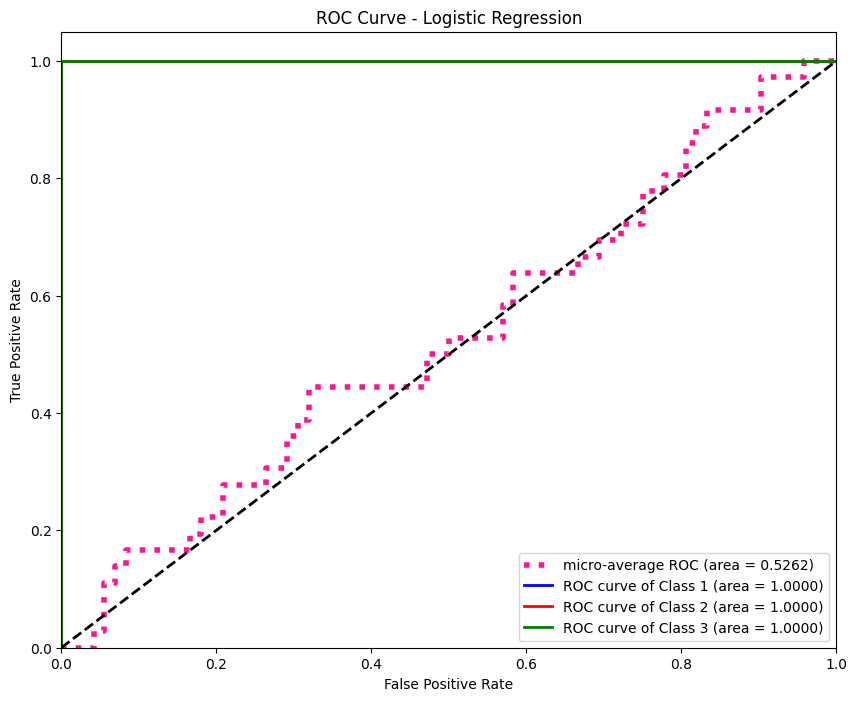

Average ROC-AUC: 0.8816


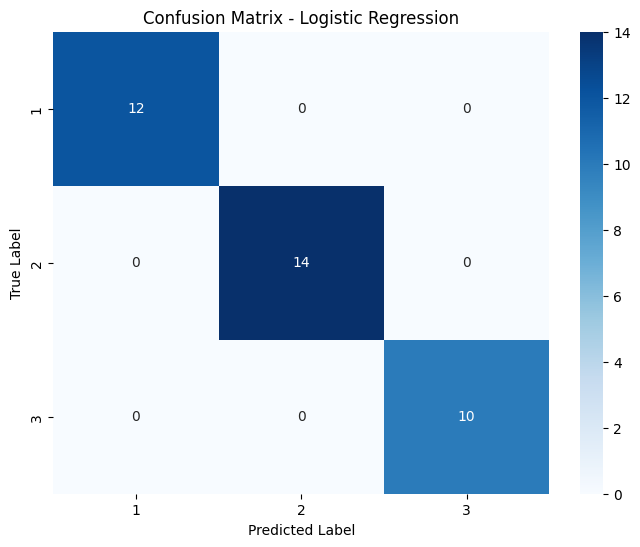


Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

K-Nearest Neighbors Evaluation:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


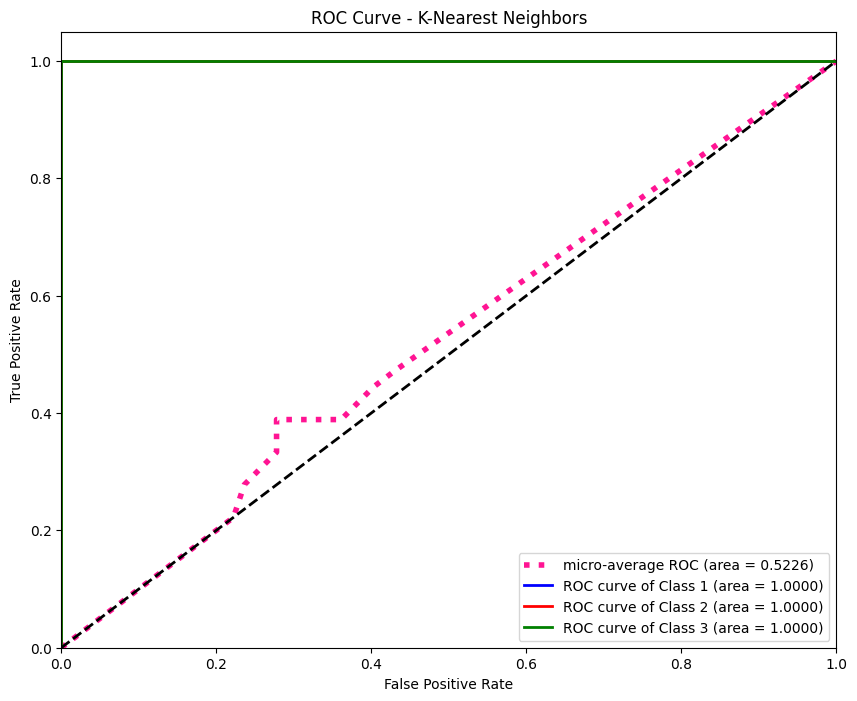

Average ROC-AUC: 0.8806


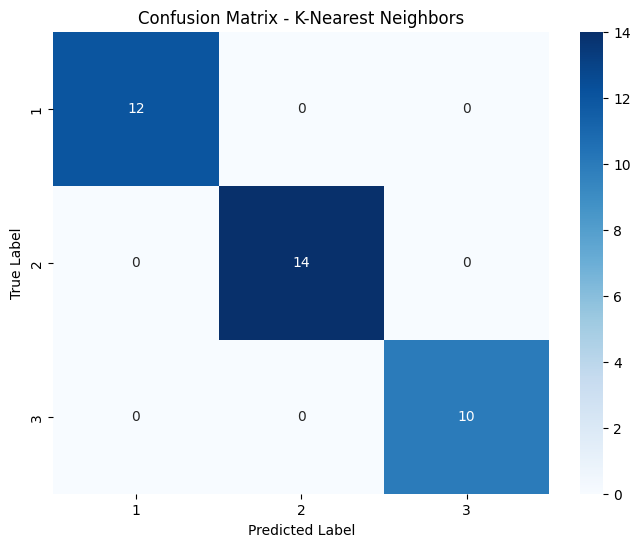


Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



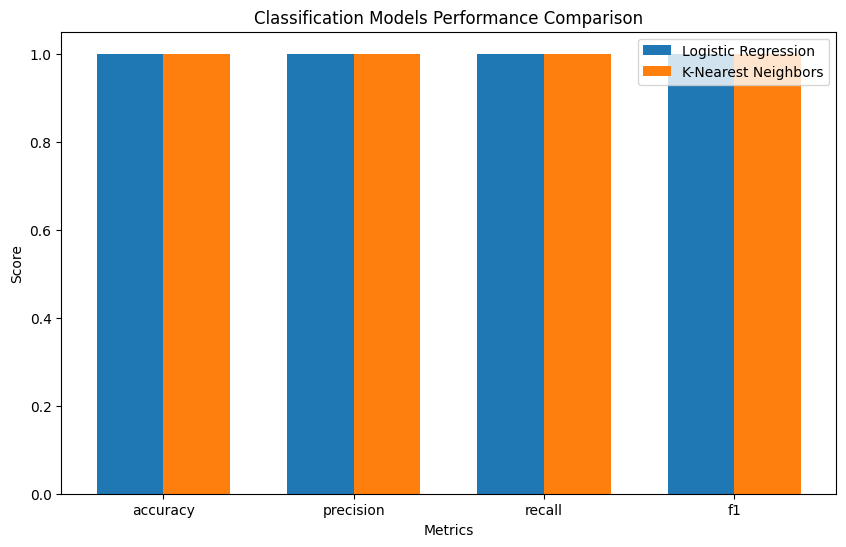

In [63]:
# Loading the best models from tuning results
best_log_reg = log_grid.best_estimator_
best_knn = knn_grid.best_estimator_

# Make predictions
y_pred_log = best_log_reg.predict(X_wine_test)
y_pred_knn = best_knn.predict(X_wine_test)

# Evaluate both models
log_reg_results = evaluate_classifier(best_log_reg, "Logistic Regression", X_wine_test, y_wine_test)
knn_results = evaluate_classifier(best_knn, "K-Nearest Neighbors", X_wine_test, y_wine_test)

# Compare models side by side
metrics = ['accuracy', 'precision', 'recall', 'f1']
model_names = ['Logistic Regression', 'K-Nearest Neighbors']
results = [log_reg_results, knn_results]

# Create comparison bar chart
plt.figure(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(metrics))

for i, (name, result) in enumerate(zip(model_names, results)):
    values = [result[metric] for metric in metrics]
    plt.bar(index + i*bar_width, values, bar_width, label=name)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Classification Models Performance Comparison')
plt.xticks(index + bar_width/2, metrics)
plt.ylim(0, 1.05)
plt.legend()
plt.show()

#### **Regression Models**

In [64]:
# Add confidence ellipse
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if x.size != y.size:
        raise ValueError("x and y must be the same size")
        
    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    
    # Using a special case to obtain the eigenvalues of this
    # two-dimensional dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, **kwargs)
    
    # Calculating the standard deviation of x from the square root of the variance
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    
    # Calculating the standard deviation of y from the square root of the variance
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)
    
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
        
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

In [65]:
# Creating a function for comprehensive regression evaluation
def evaluate_regressor(model, model_name, X_test, y_test):
    # Get predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    explained_var = explained_variance_score(y_test, y_pred)
    
    print(f"{model_name} Evaluation")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Explained Variance: {explained_var:.4f}")
    
    # Prediction scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual Quality')
    plt.ylabel('Predicted Quality')
    plt.title(f'{model_name}: Actual vs Predicted Quality')
    
    confidence_ellipse(y_test, y_pred, plt.gca(), edgecolor='red', facecolor='none', 
                      label='95% Confidence Region')
    
    plt.legend()
    plt.show()
    
    # Residual plot
    residuals = y_test - y_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Quality')
    plt.ylabel('Residuals')
    plt.title(f'{model_name}: Residual Plot')
    
    # Add a histogram of residuals
    plt.figure(figsize=(10, 6))
    plt.hist(residuals, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(x=0, color='r', linestyle='--')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.title(f'{model_name}: Distribution of Residuals')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Prediction error distribution across quality levels
    plt.figure(figsize=(10, 6))
    error_df = pd.DataFrame({
        'Actual': y_test,
        'Predicted': y_pred,
        'Error': np.abs(y_test - y_pred)
    })
    error_by_quality = error_df.groupby('Actual').agg({'Error': ['mean', 'std', 'count']})
    error_by_quality.columns = ['Mean Error', 'Std Error', 'Count']
   
    
    return {
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'explained_var': explained_var,
        'predictions': y_pred,
        'residuals': residuals
    }

In [67]:
# Creating comparison bar chart for regression metrics
def compare_regression_models(model_results, dataset_name):
    metrics = ['mae', 'rmse', 'r2']
    metric_names = ['MAE', 'RMSE', 'R²']
    model_names = list(model_results.keys())
    
    # For R², we want higher values, for errors lower values
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Error metrics (lower is better)
    error_metrics = ['mae', 'rmse']
    error_labels = ['MAE', 'RMSE']
    
    x = np.arange(len(error_labels))
    width = 0.35
    
    for i, (model, results) in enumerate(model_results.items()):
        values = [results[metric] for metric in error_metrics]
        ax1.bar(x + i*width, values, width, label=model)
    
    ax1.set_ylabel('Error Value (lower is better)')
    ax1.set_title(f'{dataset_name} - Error Metrics Comparison')
    ax1.set_xticks(x + width/2)
    ax1.set_xticklabels(error_labels)
    ax1.legend()
    
    # R² (higher is better)
    r2_values = [results['r2'] for model, results in model_results.items()]
    ax2.bar(model_names, r2_values)
    ax2.set_ylabel('R² Score (higher is better)')
    ax2.set_title(f'{dataset_name} - R² Comparison')
    ax2.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

Linear Regression (Red Wine) Evaluation
Mean Absolute Error: 0.5013
Mean Squared Error: 0.3847
Root Mean Squared Error: 0.6203
R² Score: 0.4113
Explained Variance: 0.4123


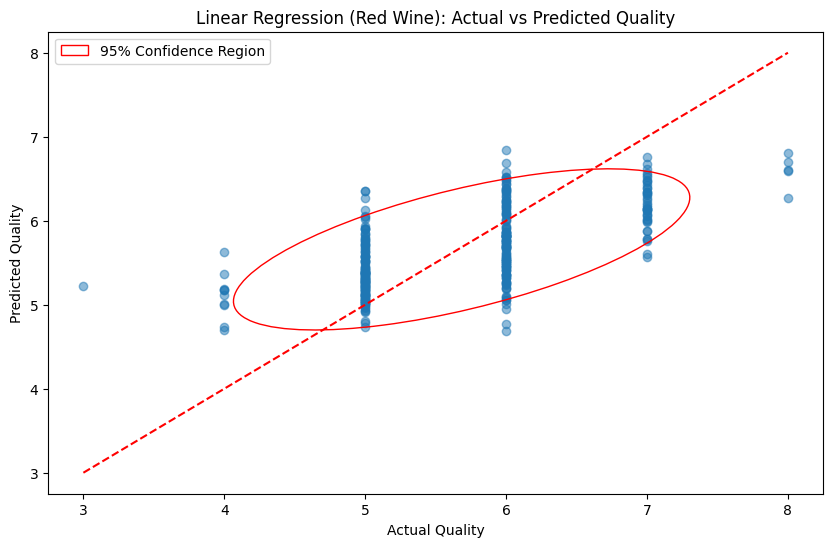

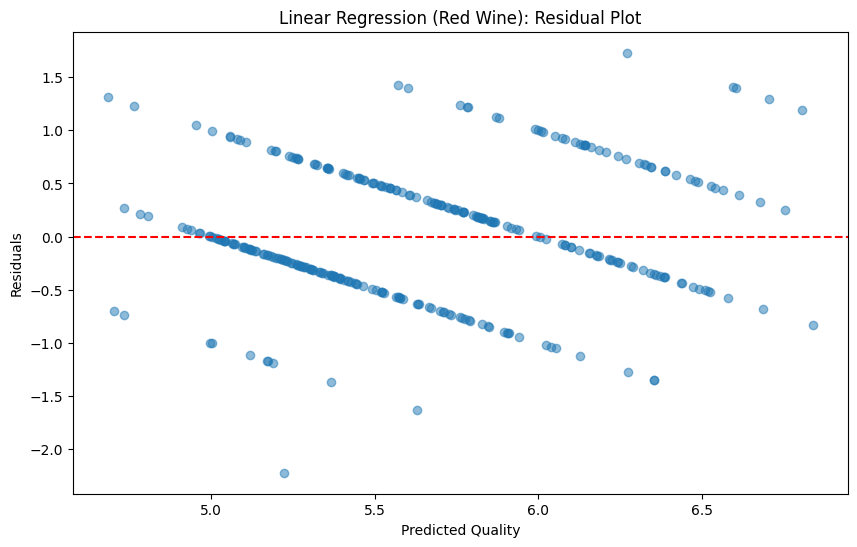

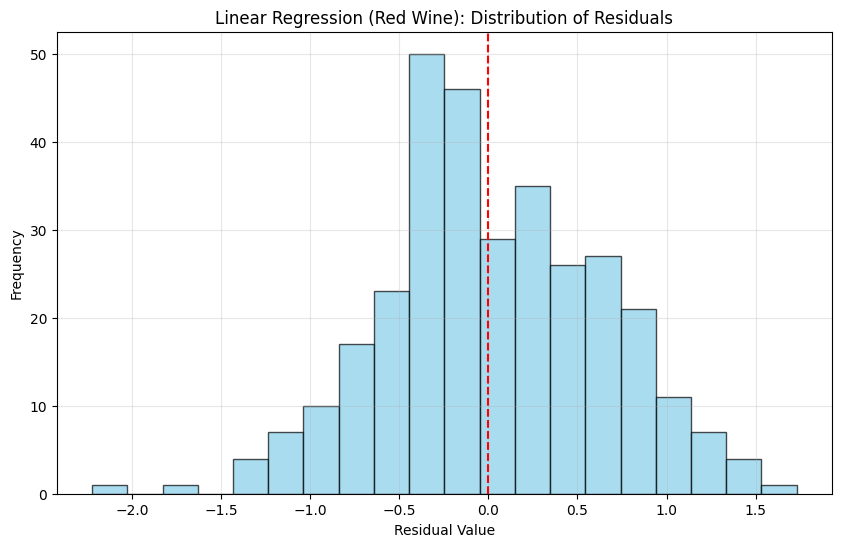

MLP Regressor (Red Wine) Evaluation
Mean Absolute Error: 0.4171
Mean Squared Error: 0.2742
Root Mean Squared Error: 0.5236
R² Score: 0.5804
Explained Variance: 0.5817


<Figure size 1000x600 with 0 Axes>

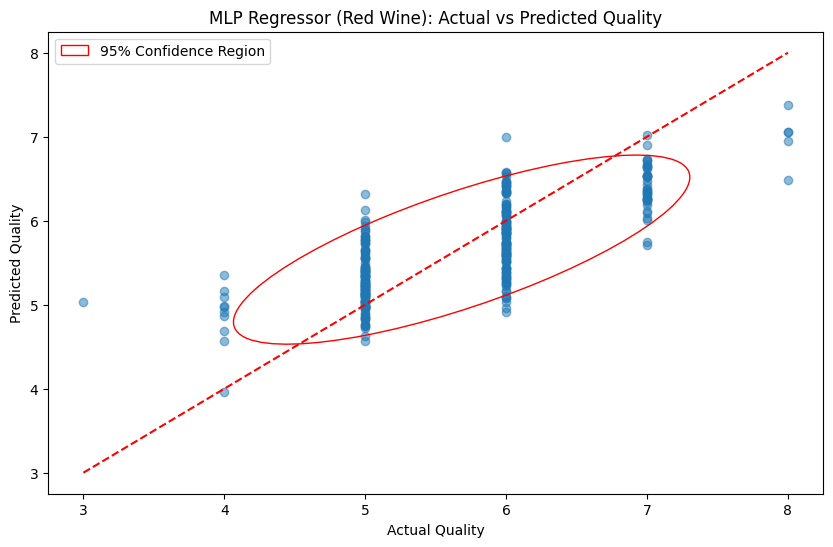

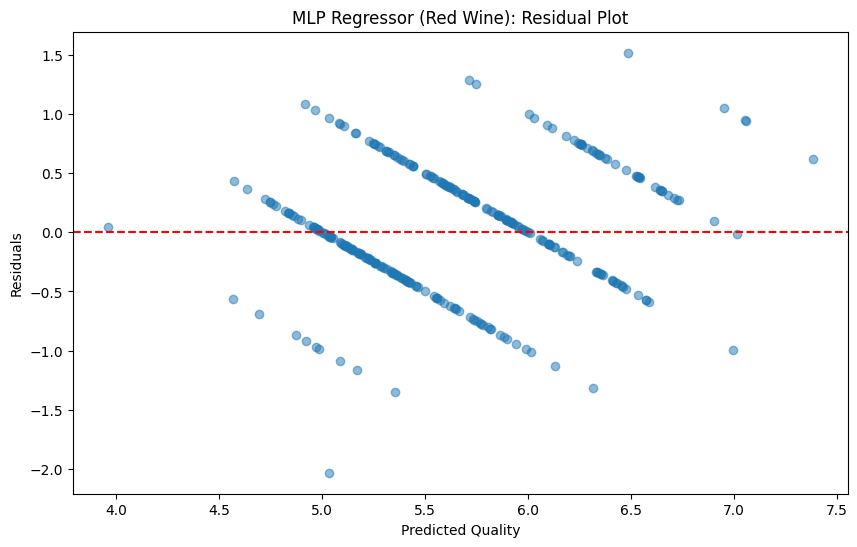

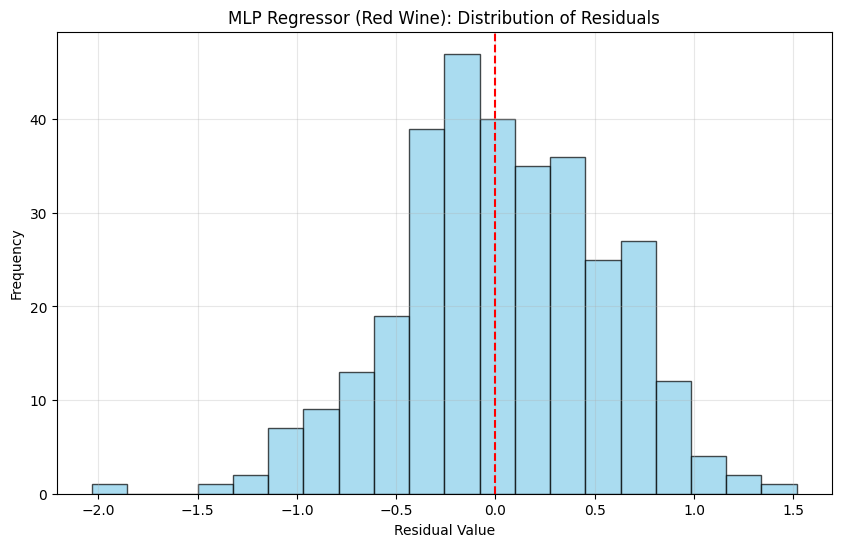

Linear Regression (White Wine) Evaluation
Mean Absolute Error: 0.5842
Mean Squared Error: 0.5609
Root Mean Squared Error: 0.7489
R² Score: 0.2758
Explained Variance: 0.2759


<Figure size 1000x600 with 0 Axes>

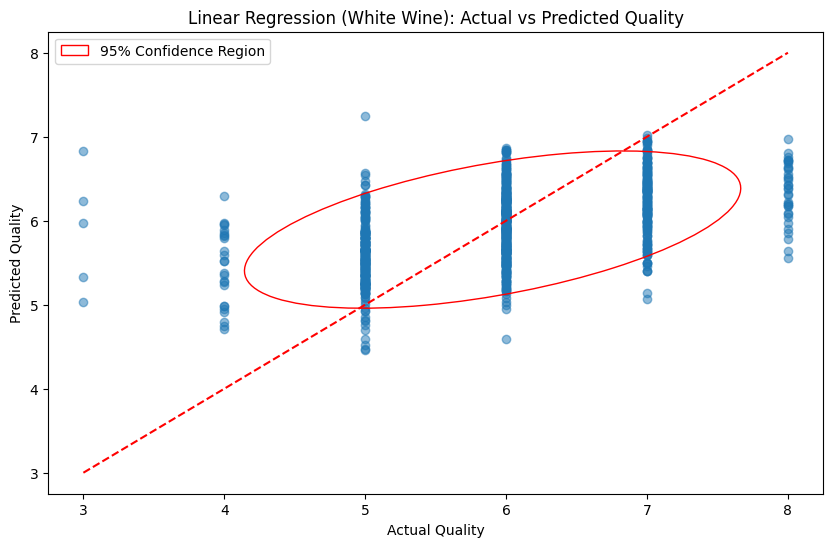

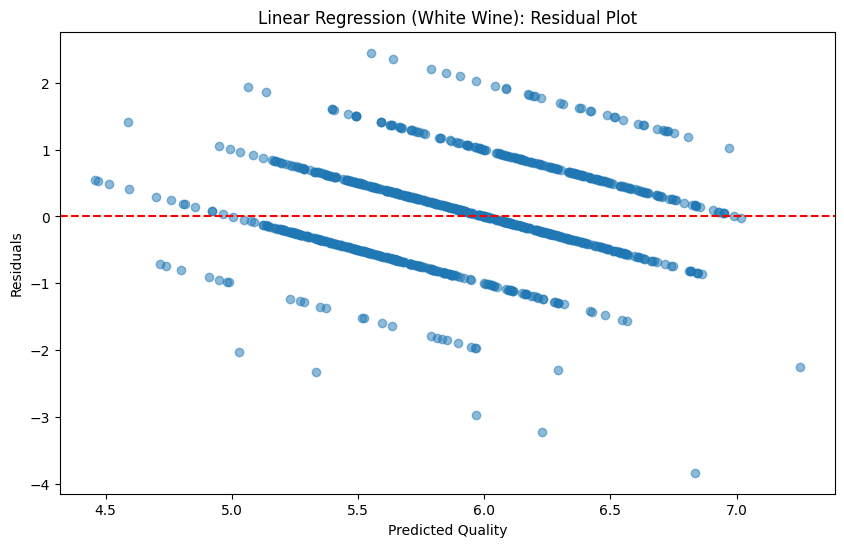

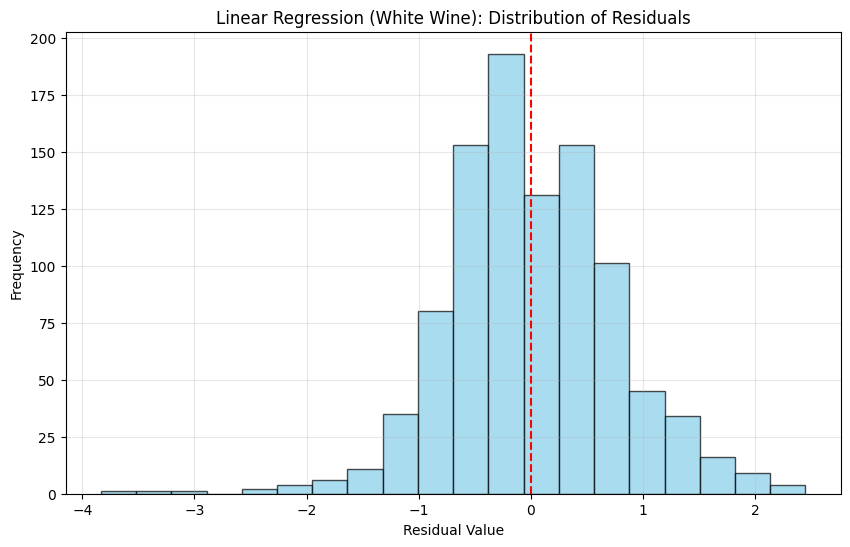

MLP Regressor (White Wine) Evaluation
Mean Absolute Error: 0.5093
Mean Squared Error: 0.4192
Root Mean Squared Error: 0.6475
R² Score: 0.4587
Explained Variance: 0.4587


<Figure size 1000x600 with 0 Axes>

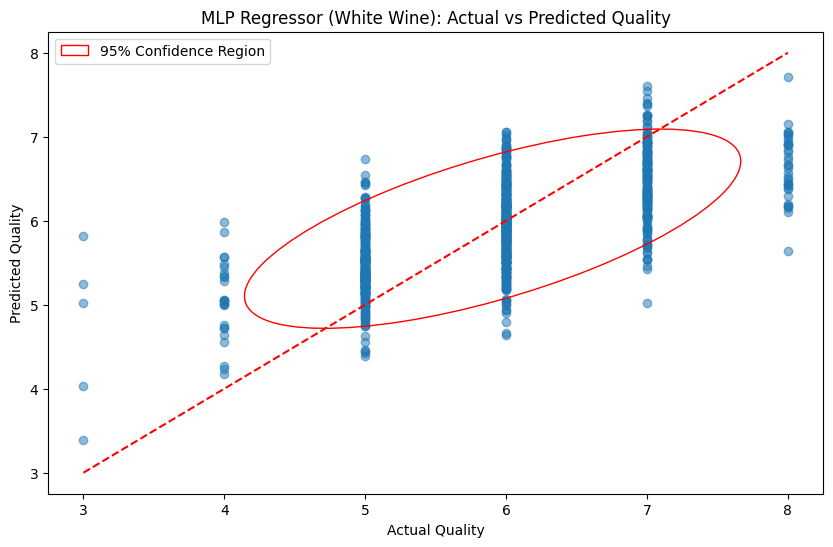

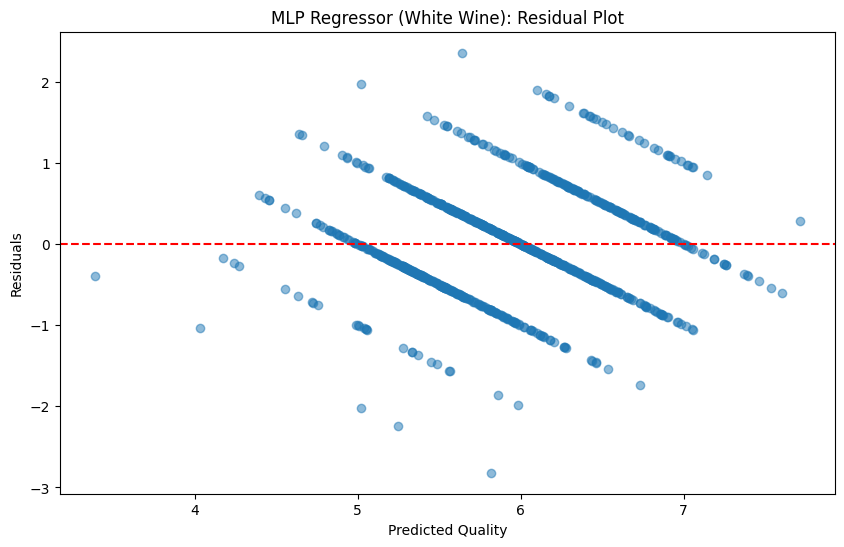

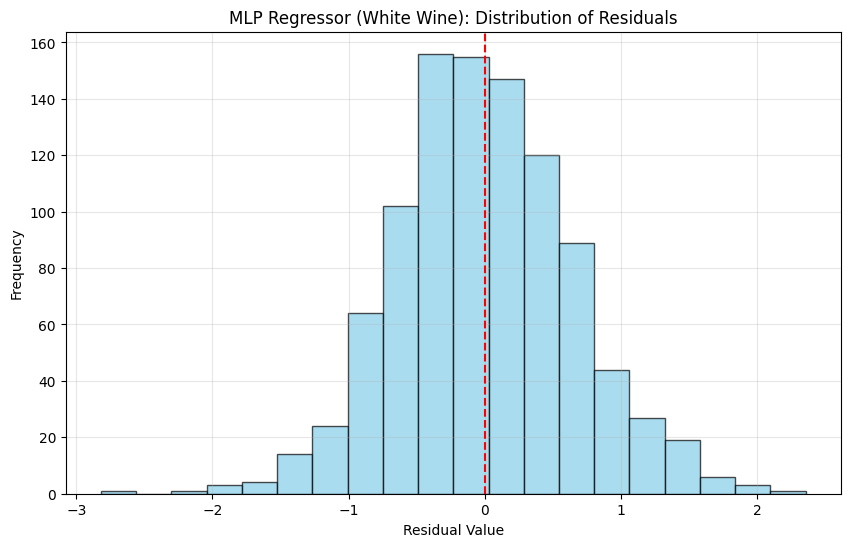

<Figure size 1000x600 with 0 Axes>

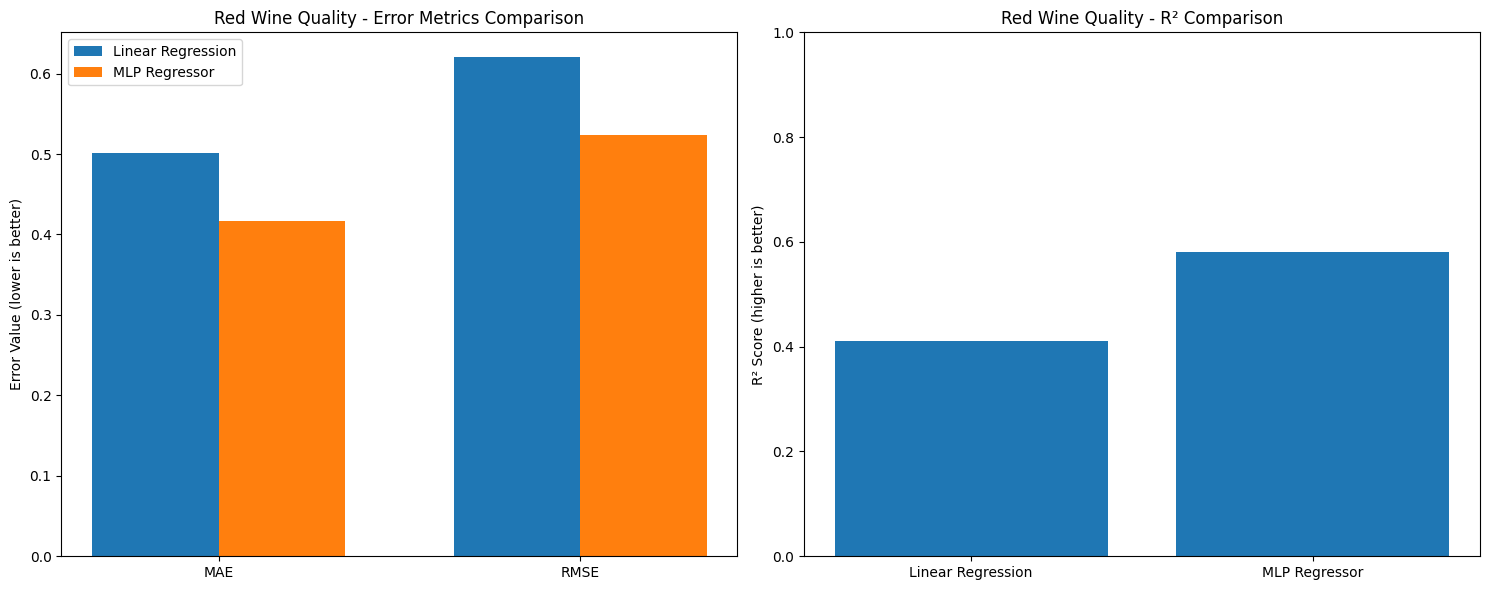

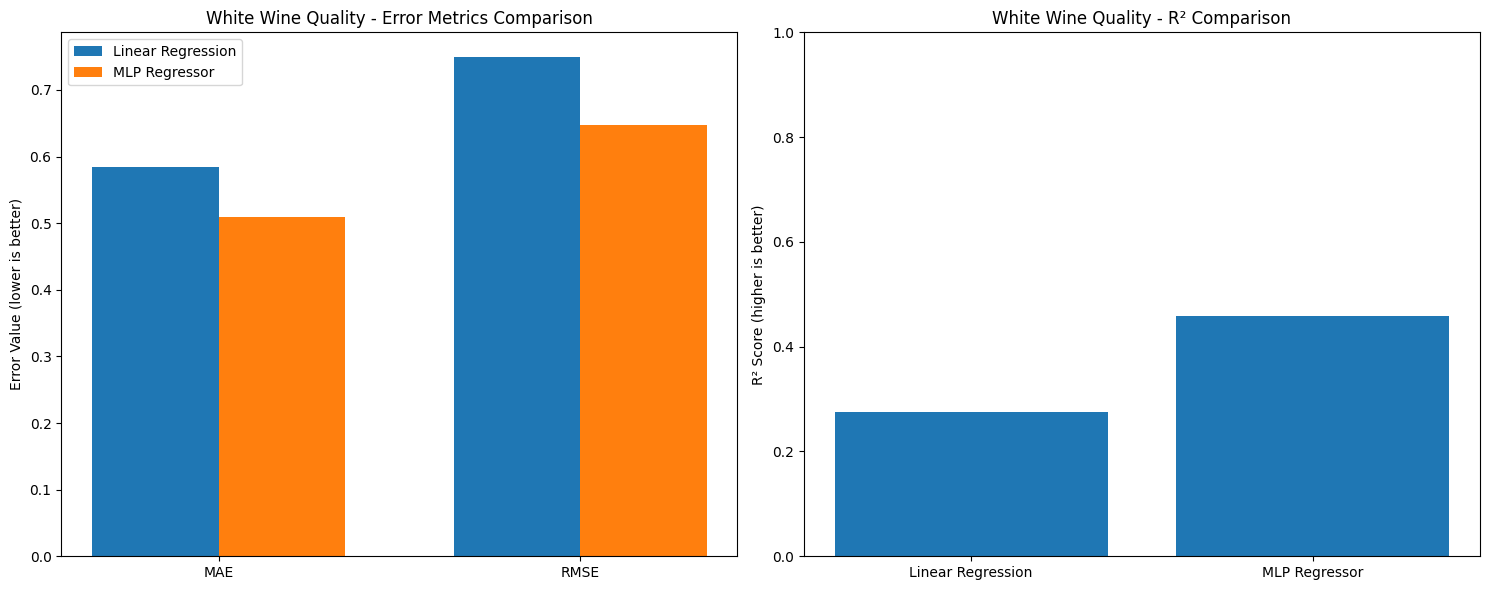

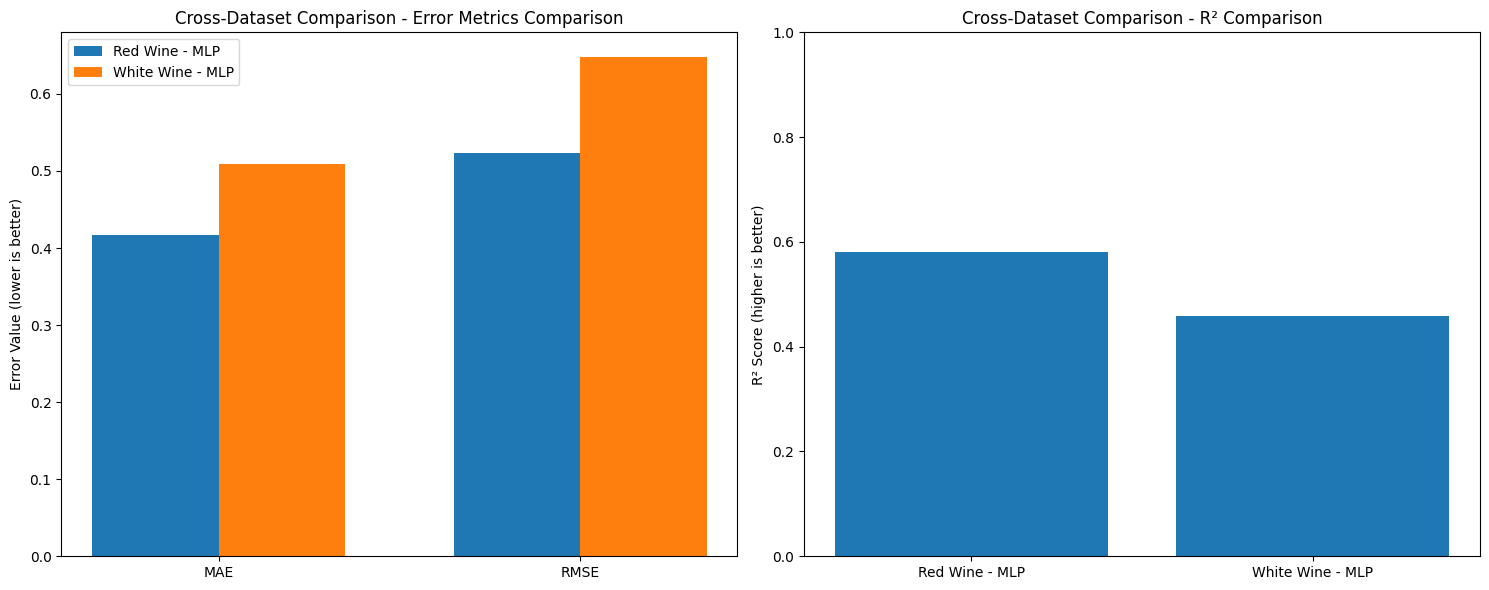

In [68]:
# Evaluating Red Wine models
red_lin_results = evaluate_regressor(best_lin_reg, "Linear Regression (Red Wine)", X_Red_test, y_Red_test)
red_mlp_results = evaluate_regressor(best_mlp, "MLP Regressor (Red Wine)", X_Red_test, y_Red_test)

# Evaluating White Wine models
white_lin_results = evaluate_regressor(best_lin_reg_white, "Linear Regression (White Wine)", X_white_test, y_white_test)
white_mlp_results = evaluate_regressor(best_mlp_white, "MLP Regressor (White Wine)", X_white_test, y_white_test)

# Compare Red Wine models
red_model_results = {
    'Linear Regression': red_lin_results,
    'MLP Regressor': red_mlp_results
}
compare_regression_models(red_model_results, 'Red Wine Quality')

# Compare White Wine models
white_model_results = {
    'Linear Regression': white_lin_results,
    'MLP Regressor': white_mlp_results
}
compare_regression_models(white_model_results, 'White Wine Quality')

# Cross-dataset comparison of best models
best_models = {
    'Red Wine - MLP': red_mlp_results,
    'White Wine - MLP': white_mlp_results
}
compare_regression_models(best_models, 'Cross-Dataset Comparison')

#### **Comparing All Models**

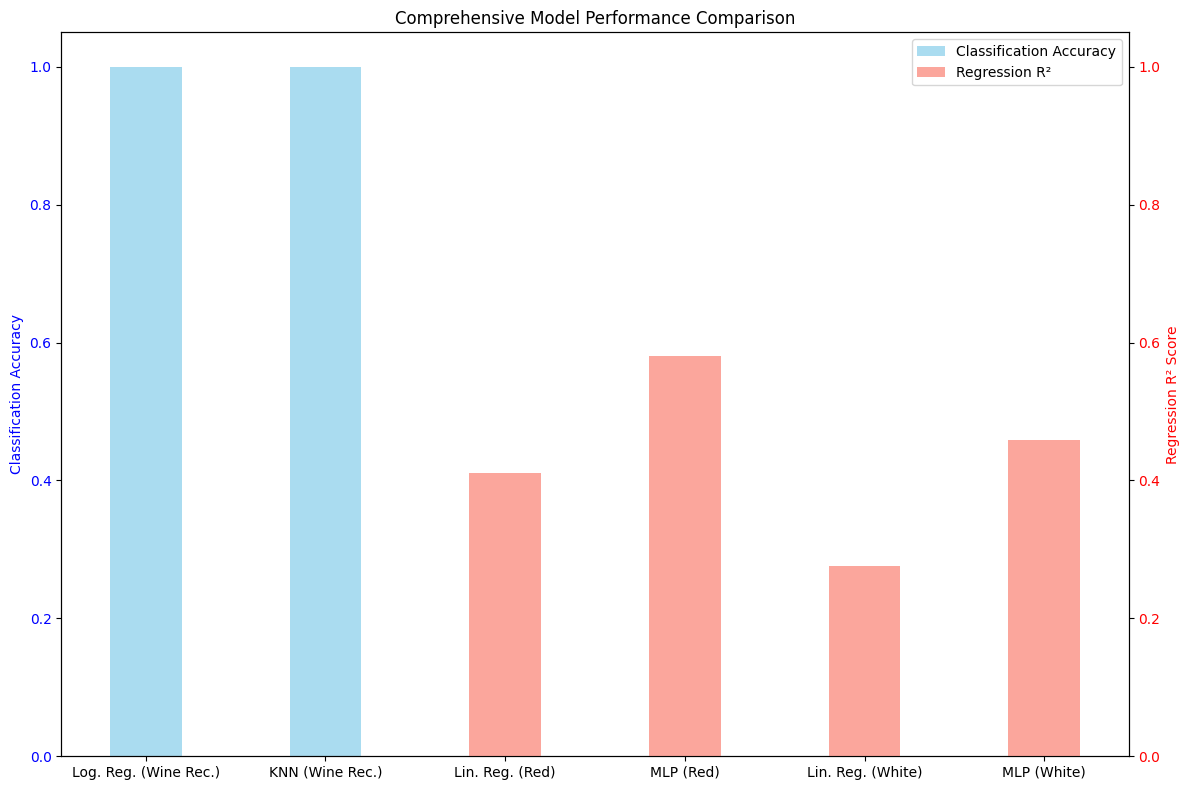

In [70]:
plt.figure(figsize=(12, 8))

# Classification accuracy (left y-axis)
ax1 = plt.subplot(111)
class_models = ['Log. Reg. (Wine Rec.)', 'KNN (Wine Rec.)']
class_acc = [log_reg_results['accuracy'], knn_results['accuracy']]
x_class = np.arange(len(class_models))
ax1.bar(x_class, class_acc, width=0.4, alpha=0.7, color='skyblue', label='Classification Accuracy')
ax1.set_ylabel('Classification Accuracy', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(0, 1.05)

# Add R² scores for regression models (right y-axis)
ax2 = ax1.twinx()
reg_models = ['Lin. Reg. (Red)', 'MLP (Red)', 'Lin. Reg. (White)', 'MLP (White)']
r2_scores = [red_lin_results['r2'], red_mlp_results['r2'], white_lin_results['r2'], white_mlp_results['r2']]
x_reg = np.arange(len(class_models), len(class_models) + len(reg_models))
ax2.bar(x_reg, r2_scores, width=0.4, alpha=0.7, color='salmon', label='Regression R²')
ax2.set_ylabel('Regression R² Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1.05)

# Set x-axis ticks and labels
plt.xticks(np.arange(len(class_models) + len(reg_models)), class_models + reg_models, rotation=45, ha='right')
plt.title('Comprehensive Model Performance Comparison')
plt.tight_layout()

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()

#### **Literature Comparison**

**Classification Models**

These classification models (Logistic Regression and KNN) achieved 100% test accuracy and surpassed the reported accuracies of 78-96% in Dhaliwal's study. This performance difference can be attributed to several factors:
- Extensive hyperparameter tuning likely contributed to performance compared to default parameters used in some prior studies.
- Good data processing approaches like feature scaling ensured that all variables contributed appropriately to the models.
- With only 36 (20% of 178) test samples, there's a higher chance of achieving perfect accuracy by chance.

**Regression Models**

Direct comparison is challenging of wine quality models is difficult because Ramya et al. treated it as a classification problem (converting scores to categories) and on the other hand, here we approached wine quality as a regression problem (predicting the numeric score 3-9)
- The paper's stated that their non-linear models (ANNs) outperformed linear approaches, similarly here MLP Regressor outperformed Linear Regression.
- Both found that red wine is more predictable than white wine.
- Ramya et al. reported that they found success with PCA-driven approaches and here we didn't explore it. So, this suggests feature engineering could further improve these models.

#### **Reflection on Our Models**

**Strengths**

- HyperParameter tuning like Grid Search and Randomized Search approaches enhanced model performance significantly.
- Used multile metrics for both Classification (accuracy, precision, recall, F1, ROC-AUC) and Regression (MAE, RMSE, R²).
- Used multiple visualization tools like confusion matrices, ROC curves, and residual plots which provideded deeper insights into model behavior.
- The Classification models (Logistic Regression and KNN) performed perfectly.


**Limitation**

- Even the best regression models explained only 46-58% of variance in wine quality which suggests that the important factors may be missing from the available features.
- The discrete nature of quality scores (integers 3-9) can be better addressed through ordinal regression approaches.
- Perfect classification accuracy on the test set can raise concerns about overfitting.
- Linear Regression provided clear coefficient interpretations but on the other hand the bette performing MLP models lack straightforward interpretability.

**Real World Relevance**

- Classification models could be used to verify wine cultivars based on chemical analysis, which could detect fraud wines.
- Regression models even without performing well can still help winemakers understanding key factors about wine quality.
- Feature importance analysis can help winemakers identify which chemical properties strongly influence wine quality.
- These models can be used in applications which recommend wines based on chemical profiles of users.
- Wine type can be identified without expert tasting.